<a href="https://colab.research.google.com/github/sgruyzcki/DiploDatos2026/blob/Rama_Sergio/An%C3%A1lisis%20Exploratorio%20y%20Curaci%C3%B3n%20de%20Datos/parte%202/EyCD_2026_Entregable_Parte_2_Grupo_3_Sergio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**
Grupo 3:

- BAGGINI, Mariano

- DA SILVA, Rocio

- GRUZYCKI, Sergio

- NEDEL, Agustina

----

# Trabajo práctico entregable - parte 2

En esta notebook, vamos a cargar el conjunto de datos de [la compentencia Kaggle](https://www.kaggle.com/dansbecker/melbourne-housing-snapshot) sobre estimación de precios de ventas de propiedades en Melbourne, Australia.

Utilizaremos el conjunto de datos reducido producido por [DanB](https://www.kaggle.com/dansbecker). Hemos subido una copia a un servidor de la Universidad Nacional de Córdoba para facilitar su acceso remoto.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
sns.set_context('talk')
import plotly.express as px

from sqlalchemy import create_engine, text

## Ejercicio 1 SQL:

1. Crear una base de datos en SQLite utilizando la libreria [SQLalchemy](https://stackoverflow.com/questions/2268050/execute-sql-from-file-in-sqlalchemy).
https://docs.sqlalchemy.org/en/14/core/engines.html#sqlite

2. Ingestar los datos provistos en 'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv' en una tabla y el dataset generado en clase con datos de airbnb y sus precios por codigo postal en otra.

3. Validar tipos de columnas antes de guardar. Usá `df.dtypes` para ver los tipos actuales. Prestá especial atención a columnas como `Date` y `Price`: por ejemplo, `Date` puede estar como string en vez de datetime, y `Price` puede venir como string o float. El método `to_sql()` infiere tipos automáticamente, pero puede fallar si los tipos no son los esperados.

4. Implementar consultas en SQL que respondan con la siguiente información:

    - cantidad de registros totales por `Regionname`.
    - cantidad de registros totales por `Suburb` y `Regionname`.
    - Consulta con filtro: ¿Cuántas propiedades hay por `Regionname` con más de 2 habitaciones?
    - Agregación condicional: ¿Cuál es el precio promedio de propiedades según tipo (`Type`) y `Regionname`?
    - Orden y límites: Mostrá el top 5 barrios con propiedades más caras en promedio.

5. Combinar los datasets de ambas tablas ingestadas utilizando el comando JOIN de SQL para obtener un resultado similar a lo realizado con Pandas en clase.

6. Agregar una celda de validación posterior al JOIN con assertions o validación de esquema. Como mínimo, verificá que el número de filas no cambió, que no aparecieron nulos inesperados y que los rangos de variables agregadas sean razonables. Esta validación implementa dimensiones básicas de calidad de datos como validez, completitud e integridad.



## Resolución Ejercicio 1

### Tratamiento del Dataset de Melbourne

In [2]:
# Dataset de propiedades de Melbourne
melb_data = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_data[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


In [3]:
# Estudio de propiedades del dataset
melb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

#### Limpieza

Se siguió en gran medida el mismo proceso de limpieza realizado en la parte 1 del entregable para este dataset. La columna `Postcode` se guarda como variable entera para compatibilizar tipo con `Zipcode` del otro dataset, y se utilizó la columna `Date` para generar las columnas `SaleMonth` y `SaleYear`, en lugar de utilizar `Semester`.

In [4]:
# Copia de trabajo: no incluye BuildingArea ni YearBuilt
melb_df = melb_data.drop(['BuildingArea', 'YearBuilt'], axis=1).copy()

In [5]:
# Estudio de valores faltantes y ceros por columna
faltantes = melb_df.isna().sum()
ceros = (melb_df == 0).sum()
resumen = pd.DataFrame({'Faltantes': faltantes, 'Ceros': ceros})
resumen[resumen.any(axis=1)]

,Faltantes,Ceros
Distance,0,6
Bedroom2,0,16
Bathroom,0,34
Car,62,1026
Landsize,0,1939
CouncilArea,1369,0


Se observan 1026 registros de propiedades sin cochera, es decir con `Car = 0`. Los 62 casos en los que `Car = Null` se descartan sin pérdida de generalidad.

In [6]:
# Eliminamos columnas faltantes en la variable Car
melb_df = melb_df.dropna(subset=['Car'])

In [7]:
# Eliminamos columnas faltantes en la variable Car
melb_df = melb_df.dropna(subset=['Car'])

In [8]:
missing_values_count = melb_df.isna().sum()
missing_values_count[missing_values_count > 0]

,0
CouncilArea,1307


Como `CouncilArea` es una variable categórica, se decidió conservar los casos faltantes creando una nueva categoría `Desconocido` para no perder observaciones.

In [9]:
melb_df['CouncilArea'] = melb_df['CouncilArea'].fillna('Desconocido')
# Conteo de valores faltantes
melb_df.isna().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


In [10]:
# Estudio de los casos en los que Distance = 0
melb_df[melb_df['Distance'] == 0][['Suburb', 'Distance', 'Regionname']].head(10)

,Suburb,Distance,Regionname
9620,Melbourne,0.0,Northern Metropolitan
10393,Melbourne,0.0,Northern Metropolitan
10739,Melbourne,0.0,Northern Metropolitan
11428,Melbourne,0.0,Northern Metropolitan
12073,Melbourne,0.0,Northern Metropolitan
12074,Melbourne,0.0,Northern Metropolitan


Se analizaron los registros con `Distance = 0` y se observó que todos corresponden al suburbio Melbourne. Estos casos pueden interpretarse como propiedades ubicadas en el centro principal de la ciudad. Por lo tanto, se considera un valor válido y no un dato faltante codificado.

In [11]:
# Estudio de la relación entre Bedrooms2 y Rooms
pd.crosstab(melb_df['Bedroom2'], melb_df['Rooms'])

Rooms,1,2,3,4,5,6,7,8,10
Bedroom2,,,,,,,,,
0.0,0,5,8,3,0,0,0,0,0
1.0,660,21,5,2,0,0,0,0,0
2.0,16,3513,162,19,1,0,0,0,0
3.0,2,74,5597,175,18,1,0,0,0
4.0,0,8,73,2469,42,4,0,1,0
5.0,0,1,5,15,531,2,2,0,0
6.0,0,0,0,0,2,59,0,2,0
7.0,0,0,0,0,1,1,8,0,0
8.0,0,0,0,0,1,0,0,4,0


Se observan muchos casos en los que `Bedroom2 > Rooms`, lo cual carece de sentido. No es posible tener una cantidad de dormitorios superior al número de ambientes que tiene la propiedad. Como `Bedroom2` se obtuvo de fuentes externas y la información que aporta distorciona la interpretación del dataset, se opta por eliminarla y conservar únicamente la columna `Rooms`.

In [12]:
melb_df = melb_df.drop('Bedroom2', axis=1)

In [13]:
# Estudio de la relación entre Bathroom y Rooms
pd.crosstab(melb_df['Bathroom'], melb_df['Rooms'])

Rooms,1,2,3,4,5,6,7,8,10
Bathroom,,,,,,,,,
0.0,1,19,11,3,0,0,0,0,0
1.0,671,3093,3233,451,17,2,0,0,0
2.0,6,502,2447,1718,260,20,3,2,0
3.0,0,8,153,468,244,35,5,2,1
4.0,0,0,5,41,47,9,2,2,0
5.0,0,0,1,2,25,0,0,0,0
6.0,0,0,2,0,2,1,0,0,0
7.0,0,0,0,0,1,0,0,1,0
8.0,0,0,0,1,0,0,0,1,0


Se observan algunos puntos de interés en esta tabla:

- Casos `Bathroom > Rooms`: Extraño que una propiedad tenga más baños que ambientes, sería correcto eliminar.

- `Casos Bathroom = 0`: Puede ser un indicador de pobreza, aunque esto debe verificarse con los demás indicadores (pocos ambientes, construcción pequeña, etc). En casas grandes, se interpreta como error de tipeo.

Tratamiento: Se codifican como `NA` los casos `Bathroom = 0` para posteriormente eliminarlos. Del mismo modo, se eliminan los casos `Bathroom > Rooms`.

No se analiza el caso de ausencia de baños como posible indicador de pobreza.

In [14]:
melb_df.loc[melb_df['Bathroom'] < 1, 'Bathroom'] = pd.NA
melb_df.loc[melb_df['Bathroom'] > melb_df['Rooms'], 'Bathroom'] = pd.NA
melb_df = melb_df.dropna(subset=['Bathroom'])
melb_df.shape[0]

13456

Los casos `Landsize = 0` se consideran como dato faltante codificado. Tratamiento: se eliminan. Luego se eliminan outliers extremos utilizando percentiles.

También se eliminan las filas que no tienen precio, es decir `Price = 0` o `Price = Null`.

In [15]:
# Descartar casos donde Landsize = 0
melb_df = melb_df[melb_df['Landsize'] != 0]

# Eliminar outliers extremos
q99_landsize = melb_df['Landsize'].quantile(0.99)
melb_df = melb_df[(melb_df['Landsize'] < q99_landsize) | (melb_df['Landsize'].isnull())]

Análisis de variables categóricas: Se verifican los tipos de datos asignados y se hacen las correcciones necesarias.

In [16]:
# Verificacion de types en las variables
melb_df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,float64


Corrección de tipos de variables: `Propertycount`, `Bathroom` y `Car` deben ser variables numéricas enteras en lugar de reales. `Postcode` debe ser una variable compatible con la variable `zipcode` del dataset de AirBnB, por lo que se convierte también en numérica entera. `Date` se convierte a fecha.

In [17]:
# Postcode como integer
melb_df['Postcode'] = melb_df['Postcode'].astype(int)

# Propertycount como integer
melb_df['Propertycount'] = melb_df['Propertycount'].astype(int)

# Car como integer
melb_df['Car'] = melb_df['Car'].astype(int)

# Bathroom como integer
melb_df['Bathroom'] = melb_df['Bathroom'].astype(int)

# Date como fecha
melb_df['Date'] = pd.to_datetime(melb_df['Date'], dayfirst=True)

melb_df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,datetime64[ns]
Distance,float64
Postcode,int64


In [18]:
# Se discrimina el mes y el año de la venta en columnas independientes
melb_df['SaleYear']  = melb_df['Date'].dt.year
melb_df['SaleMonth'] = melb_df['Date'].dt.month

# Descartar la columna original
melb_df = melb_df.drop(columns=['Date'], axis=1)

melb_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11423 entries, 0 to 13579
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         11423 non-null  object 
 1   Address        11423 non-null  object 
 2   Rooms          11423 non-null  int64  
 3   Type           11423 non-null  object 
 4   Price          11423 non-null  float64
 5   Method         11423 non-null  object 
 6   SellerG        11423 non-null  object 
 7   Distance       11423 non-null  float64
 8   Postcode       11423 non-null  int64  
 9   Bathroom       11423 non-null  int64  
 10  Car            11423 non-null  int64  
 11  Landsize       11423 non-null  float64
 12  CouncilArea    11423 non-null  object 
 13  Lattitude      11423 non-null  float64
 14  Longtitude     11423 non-null  float64
 15  Regionname     11423 non-null  object 
 16  Propertycount  11423 non-null  int64  
 17  SaleYear       11423 non-null  int32  
 18  SaleMonth  

In [19]:
# Cantidad de ventas realizadas agrupadas por mes y discriminadas por año
melb_df.groupby(['SaleYear', 'SaleMonth']).size()

SaleYear  SaleMonth
2016      1               2
          2              22
          4             254
          5             706
          6             569
          7             350
          8             562
          9             732
          10            441
          11            889
          12            494
2017      2             347
          3             547
          4             509
          5            1004
          6            1000
          7            1355
          8             773
          9             867
dtype: int64

#### Resultado: Limpieza del dataset de Melbourne.

El dataset `melb_df` no tiene valores nulos; se descartó la columna `Bedroom2` y las entradas en las que:

- `Bathroom = 0`
- `Bathroom > Rooms`
- `Landsize = 0`

También se hizo un filtro de outliers al 99% en `Landsize`.

Se codificaron valores nulos de `CouncilArea` como `Desconocido`.

Se descartó la columna `Date`, codificando su información en las columnas `SaleYear` y `SaleMonth`.

Además, todos los tipos de datos fueron debidamente corregidos.

### Tratamiento del Dataset de AirBnB

In [20]:
# Dataset de propiedades de AirBnB (completo)
airbnb_data = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/cleansed_listings_dec18.csv')
airbnb_data[:3]

/tmp/ipykernel_4802/1353126128.py:2: DtypeWarning: Columns (35,77) have mixed types. Specify dtype option on import or set low_memory=False.
  airbnb_data = pd.read_csv(


,id,listing_url,scrape_id,last_scraped,name,summary,space,description,neighborhood_overview,notes,...,review_scores_location,review_scores_value,requires_license,license,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,9835,https://www.airbnb.com/rooms/9835,2.018120e+13,12/7/2018,Beautiful Room & House,NaN,"House: Clean, New, Modern, Quite, Safe. 10Km f...","House: Clean, New, Modern, Quite, Safe. 10Km f...",Very safe! Family oriented. Older age group.,NaN,...,9.0,9.0,f,NaN,f,strict_14_with_grace_period,f,f,1,0.04
1,10803,https://www.airbnb.com/rooms/10803,2.018120e+13,12/7/2018,Room in Cool Deco Apartment in Brunswick,A large air conditioned room with queen spring...,The apartment is Deco/Edwardian in style and h...,A large air conditioned room with queen spring...,This hip area is a crossroads between two grea...,NaN,...,9.0,9.0,f,NaN,t,moderate,t,t,1,1.50
2,12936,https://www.airbnb.com/rooms/12936,2.018120e+13,12/7/2018,St Kilda 1BR APT+BEACHSIDE+VIEWS+PARKING+WIFI+AC,RIGHT IN THE HEART OF ST KILDA! It doesn't get...,FREE WiFi FREE in-building remote controlled g...,RIGHT IN THE HEART OF ST KILDA! It doesn't get...,A stay at our apartment means you can enjoy so...,First floor apartment with both lift and stair...,...,9.0,9.0,f,NaN,f,strict_14_with_grace_period,f,f,17,0.15


El dataset completo tiene 84 columnas, de las cuales nos interesa sólo un número reducido. Guardamos una copia de trabajo con el filtro aplicado.

In [21]:
# Columnas de interes
interesting_cols = [
  'description', 'neighborhood_overview',
  'street', 'neighborhood', 'city', 'suburb', 'state', 'zipcode',
  'price', 'weekly_price', 'monthly_price',
  'latitude', 'longitude',
]

In [22]:
# Guardo una copia del dataset original solo con las columnas de interes
airbnb_df = airbnb_data[interesting_cols].copy()
airbnb_df[:3]

,description,neighborhood_overview,street,neighborhood,city,suburb,state,zipcode,price,weekly_price,monthly_price,latitude,longitude
0,"House: Clean, New, Modern, Quite, Safe. 10Km f...",Very safe! Family oriented. Older age group.,"Bulleen, VIC, Australia",Balwyn North,Manningham,Bulleen,VIC,3105,60,NaN,NaN,-37.772684,145.092133
1,A large air conditioned room with queen spring...,This hip area is a crossroads between two grea...,"Brunswick East, VIC, Australia",Brunswick,Moreland,Brunswick East,VIC,3057,35,200.0,803.0,-37.766505,144.980736
2,RIGHT IN THE HEART OF ST KILDA! It doesn't get...,A stay at our apartment means you can enjoy so...,"St Kilda, VIC, Australia",St Kilda,Port Phillip,St Kilda,VIC,3182,159,1253.0,4452.0,-37.859755,144.977369


In [23]:
# Estudio de propiedades del dataset
airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22895 entries, 0 to 22894
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   description            22563 non-null  object 
 1   neighborhood_overview  14424 non-null  object 
 2   street                 22895 non-null  object 
 3   neighborhood           17082 non-null  object 
 4   city                   22895 non-null  object 
 5   suburb                 22872 non-null  object 
 6   state                  22834 non-null  object 
 7   zipcode                22753 non-null  object 
 8   price                  22895 non-null  int64  
 9   weekly_price           2524 non-null   float64
 10  monthly_price          1891 non-null   float64
 11  latitude               22895 non-null  float64
 12  longitude              22895 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 2.3+ MB


#### Limpieza

Se procuró alterar el dataset lo mínimo indispensable para poder concatenarlo con el de Melbourne sin que se produzcan incompatibilidades: Se corrigieron tipos de datos y se completaron con ceros los valores faltantes de `zipcode`.

In [24]:
# Estudio de valores faltantes y ceros por columna
faltantes_airbnb = airbnb_df.isna().sum()
ceros_airbnb = (airbnb_df == 0).sum()
resumen = pd.DataFrame({'Faltantes': faltantes_airbnb, 'Ceros': ceros_airbnb})
resumen[resumen.any(axis=1)]

,Faltantes,Ceros
description,332,0
neighborhood_overview,8471,0
neighborhood,5813,0
suburb,23,0
state,61,0
zipcode,142,0
price,0,21
weekly_price,20371,0
monthly_price,21004,0


Se observan 146 valores faltantes en la columna `zipcode`. Para compatibilizar datasets, se completan con ceros y luego se convierte la variable en entera.

In [25]:
# Conversion de tipos para compatibilizar datasets
airbnb_df['zipcode'] = pd.to_numeric(airbnb_df.zipcode, errors='coerce')
airbnb_df['zipcode'] = airbnb_df.zipcode.fillna(0).astype('int')
airbnb_df.dtypes

,0
description,object
neighborhood_overview,object
street,object
neighborhood,object
city,object
suburb,object
state,object
zipcode,int64
price,int64
weekly_price,float64


In [26]:
airbnb_df[airbnb_df['zipcode'] == 0].shape

(146, 13)

In [27]:
# Agrupamos por zipcode
relevant_cols = ['price', 'weekly_price', 'monthly_price', 'zipcode']
airbnb_price_by_zipcode = airbnb_df[relevant_cols].groupby('zipcode')\
    .agg(
        airbnb_price_median=('price', 'median'),
        airbnb_record_count=('price', 'count'),
        airbnb_weekly_price_median=('weekly_price', 'median'),
        airbnb_monthly_price_median=('monthly_price', 'median')
    ).reset_index()

print(f"Dimensiones finales: {airbnb_price_by_zipcode.shape}")

Dimensiones finales: (248, 5)


### Consultas SQL

In [28]:
# Primero creamos la base de datos SQL
engine = create_engine('sqlite:///melbourne_airbnb.sqlite')

In [29]:
# Guardamos Melbourne
melb_df.to_sql('melbourne', con=engine, if_exists='replace', index=False)

# Guardar Airbnb agrupado por zipcode
airbnb_price_by_zipcode.to_sql('airbnb_by_zipcode', con=engine, if_exists='replace', index=False)

248

In [30]:
# Verificamos que se cargaron correctamente
with engine.connect() as con:
    n_melb = pd.read_sql("SELECT COUNT(*) as total FROM melbourne", con)
    n_airbnb = pd.read_sql("SELECT COUNT(*) as total FROM airbnb_by_zipcode", con)

print(f"Registros en melbourne: {n_melb['total'].values[0]}")
print(f"Registros en airbnb_by_zipcode: {n_airbnb['total'].values[0]}")

assert n_melb['total'].values[0] == len(melb_df), "¡Error: filas no coinciden!"
assert n_airbnb['total'].values[0] == len(airbnb_price_by_zipcode), "¡Error: filas no coinciden!"
print("✓ Validación OK: los conteos coinciden con los DataFrames originales.")

Registros en melbourne: 11423
Registros en airbnb_by_zipcode: 248
✓ Validación OK: los conteos coinciden con los DataFrames originales.


In [31]:
# Función auxiliar para ejecutar consultas SQL
def run_query(query, engine):
    return pd.read_sql(query, con=engine)

In [32]:
# Consultas de SQL
# 1. Cantidad de registros totales por Regionname
q1 = """
SELECT
    Regionname,
    COUNT(*) AS cantidad_registros
FROM melbourne
GROUP BY Regionname
ORDER BY cantidad_registros DESC;
"""


# 2. Cantidad de registros totales por Suburb y Regionname
q2 = """
SELECT
    Suburb,
    Regionname,
    COUNT(*) AS cantidad_registros
FROM melbourne
GROUP BY Suburb, Regionname
ORDER BY cantidad_registros DESC;
"""


# 3. Cantidad de propiedades por Regionname con más de 2 habitaciones
q3 = """
SELECT
    Regionname,
    COUNT(*) AS cantidad_propiedades_mas_2_rooms
FROM melbourne
WHERE Rooms > 2
GROUP BY Regionname
ORDER BY cantidad_propiedades_mas_2_rooms DESC;
"""


# 4. Precio promedio de propiedades según Type y Regionname
q4 = """
SELECT
    Type,
    Regionname,
    ROUND(AVG(Price), 0) AS precio_promedio
FROM melbourne
GROUP BY Type, Regionname
ORDER BY Regionname, Type;
"""


# 5. Top 5 barrios con propiedades más caras en promedio
q5 = """
SELECT
    Suburb,
    ROUND(AVG(Price), 0) AS precio_promedio,
    COUNT(*) AS cantidad_registros
FROM melbourne
GROUP BY Suburb
ORDER BY precio_promedio DESC
LIMIT 5;
"""


# 6. JOIN entre Melbourne y Airbnb agrupado por zipcode
q_join = """
SELECT
    m.*,
    a.zipcode,
    a.airbnb_price_median,
    a.airbnb_record_count,
    a.airbnb_weekly_price_median,
    a.airbnb_monthly_price_median
FROM melbourne AS m
LEFT JOIN airbnb_by_zipcode AS a
    ON m.Postcode = a.zipcode;
"""

# Ejecutar consultas y guardar resultados
resultado_q1 = run_query(q1, engine)
resultado_q2 = run_query(q2, engine)
resultado_q3 = run_query(q3, engine)
resultado_q4 = run_query(q4, engine)
resultado_q5 = run_query(q5, engine)

merged_sales_sql_df = run_query(q_join, engine)

In [33]:
# Visualización inicial resumida de los resultados
def mostrar_resultado(titulo, df, n=5):
    print("\n" + "=" * 80)
    print(titulo)
    print("=" * 80)
    display(df.head(n))

mostrar_resultado("Consulta 1: registros por Regionname", resultado_q1)
mostrar_resultado("Consulta 2: registros por Suburb y Regionname", resultado_q2, 10)
mostrar_resultado("Consulta 3: propiedades con más de 2 habitaciones por Regionname", resultado_q3)
mostrar_resultado("Consulta 4: precio promedio por Type y Regionname", resultado_q4, 10)

print("\n" + "=" * 80)
print("Consulta 5: top 5 barrios con propiedades más caras en promedio")
print("=" * 80)
display(resultado_q5)

print("\n" + "=" * 80)
print("JOIN SQL entre Melbourne y Airbnb")
print("=" * 80)
print(f"Dimensiones del dataset unido con SQL: {merged_sales_sql_df.shape}")
display(merged_sales_sql_df.head())


Consulta 1: registros por Regionname


,Regionname,cantidad_registros
0,Southern Metropolitan,3571
1,Northern Metropolitan,3229
2,Western Metropolitan,2657
3,Eastern Metropolitan,1413
4,South-Eastern Metropolitan,436



Consulta 2: registros por Suburb y Regionname


,Suburb,Regionname,cantidad_registros
0,Reservoir,Northern Metropolitan,335
1,Bentleigh East,Southern Metropolitan,239
2,Preston,Northern Metropolitan,226
3,Brunswick,Northern Metropolitan,184
4,Richmond,Northern Metropolitan,182
5,Essendon,Western Metropolitan,173
6,Coburg,Northern Metropolitan,168
7,Balwyn North,Southern Metropolitan,166
8,Glen Iris,Southern Metropolitan,164
9,Pascoe Vale,Northern Metropolitan,164



Consulta 3: propiedades con más de 2 habitaciones por Regionname


...

,Type,Regionname,precio_promedio
0,h,Eastern Metropolitan,1195188.0
1,t,Eastern Metropolitan,869769.0
2,u,Eastern Metropolitan,673574.0
3,h,Eastern Victoria,690000.0
4,u,Eastern Victoria,461333.0
5,h,Northern Metropolitan,1019696.0
6,t,Northern Metropolitan,734947.0
7,u,Northern Metropolitan,534581.0
8,h,Northern Victoria,564194.0
9,h,South-Eastern Metropolitan,956267.0



Consulta 5: top 5 barrios con propiedades más caras en promedio


,Suburb,precio_promedio,cantidad_registros
0,Kooyong,3080000.0,1
1,Canterbury,2294347.0,49
2,Malvern,2287286.0,42
3,Middle Park,2225935.0,31
4,East Melbourne,2223889.0,9



JOIN SQL entre Melbourne y Airbnb
Dimensiones del dataset unido con SQL: (11423, 24)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Distance,Postcode,Bathroom,...,Longtitude,Regionname,Propertycount,SaleYear,SaleMonth,zipcode,airbnb_price_median,airbnb_record_count,airbnb_weekly_price_median,airbnb_monthly_price_median
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2.5,3067,1,...,144.9984,Northern Metropolitan,4019,2016,12,3067.0,100.0,258.0,380.0,1440.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2.5,3067,1,...,144.9934,Northern Metropolitan,4019,2016,2,3067.0,100.0,258.0,380.0,1440.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2.5,3067,2,...,144.9944,Northern Metropolitan,4019,2017,3,3067.0,100.0,258.0,380.0,1440.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2.5,3067,2,...,144.9969,Northern Metropolitan,4019,2017,3,3067.0,100.0,258.0,380.0,1440.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2.5,3067,1,...,144.9941,Northern Metropolitan,4019,2016,6,3067.0,100.0,258.0,380.0,1440.0


In [34]:
# Validación posterior al JOIN
assert merged_sales_sql_df.shape[0] == len(melb_df), "Error: el JOIN modificó la cantidad de filas."

print("✓ Validación OK: el JOIN mantiene la cantidad de filas de Melbourne.")

✓ Validación OK: el JOIN mantiene la cantidad de filas de Melbourne.


#### Gráficos de consultas realizadas e interpretaciones

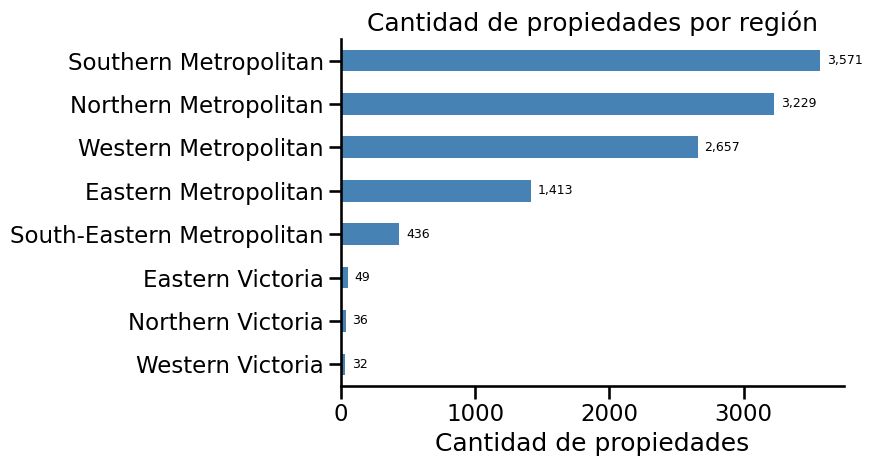

In [35]:
# Gráfico 1: Cantidad de propiedades por Regionname
resultado_q1_graf = resultado_q1.sort_values('cantidad_registros', ascending=True)

ax = resultado_q1_graf.plot(
    kind='barh',
    x='Regionname',
    y='cantidad_registros',
    legend=False,
    color='steelblue',
    figsize=(9, 5)
)

plt.title('Cantidad de propiedades por región')
plt.xlabel('Cantidad de propiedades')
plt.ylabel('')

# Agregar etiquetas al final de cada barra
for i, value in enumerate(resultado_q1_graf['cantidad_registros']):
    ax.text(
        value + 50,
        i,
        f'{value:,}',
        va='center',
        fontsize=9
    )

# Limpiar bordes
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

El gráfico muestra una distribución desigual de propiedades entre las regiones de Melbourne. Las regiones con mayor cantidad de registros son Southern Metropolitan, Northern Metropolitan y Western Metropolitan, cada una con más de 2.000 propiedades, lo que refleja una mayor concentración de observaciones en zonas metropolitanas.

En cambio, regiones como Eastern Victoria, Northern Victoria y Western Victoria presentan una cantidad mucho menor de registros, posiblemente por tratarse de zonas más periféricas o con menor actividad inmobiliaria registrada en el dataset.

Esta diferencia es importante porque las regiones con pocos registros pueden generar estimaciones menos robustas al analizar precios promedio. Por ese motivo, en consultas posteriores conviene considerar la cantidad de observaciones disponibles antes de interpretar los valores promedio.

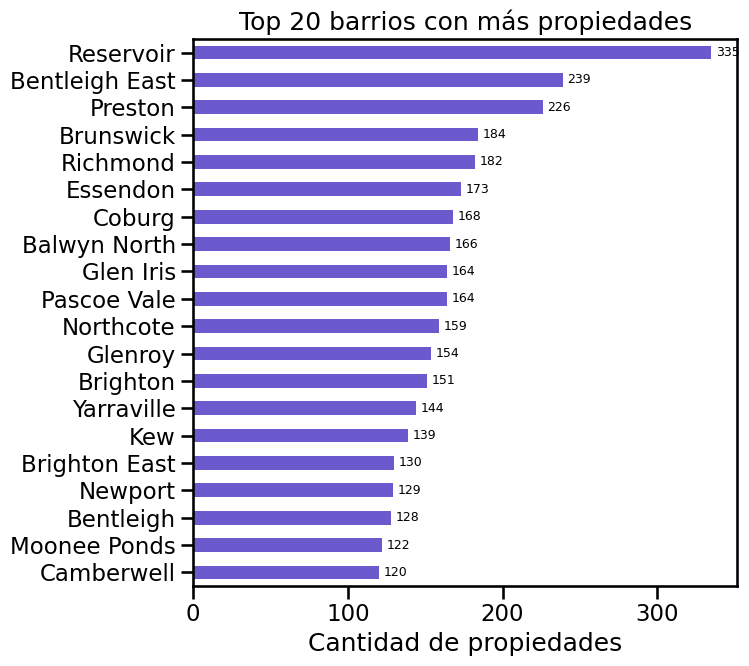

In [36]:
# Gráfico 2: Top 20 barrios con más propiedades
resultado_q2_top20 = resultado_q2.head(20)

resultado_q2_top20.plot(
    kind='barh',
    x='Suburb',
    y='cantidad_registros',
    color='slateblue',
    legend=False,
    figsize=(8, 7)
)

plt.title('Top 20 barrios con más propiedades')
plt.xlabel('Cantidad de propiedades')
plt.ylabel('')
plt.gca().invert_yaxis()

for bar in plt.gca().patches:
    valor = bar.get_width()
    plt.gca().text(
        valor + 3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(valor)}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()


El gráfico muestra los 20 barrios con mayor cantidad de propiedades registradas en el dataset. Se observa que algunos barrios concentran una cantidad considerablemente mayor de registros, lo que indica que tienen mayor presencia dentro de la base analizada.

Estos barrios pueden representar zonas con mayor actividad inmobiliaria, mayor densidad residencial o simplemente una mejor cobertura dentro del dataset. Al mismo tiempo, esta concentración implica que los análisis realizados sobre estos barrios pueden ser más representativos que aquellos aplicados sobre barrios con pocos registros.

Este resultado también permite identificar qué zonas tienen mayor peso en el dataset y podrían influir más en los análisis generales de precios, tipos de propiedad y distribución geográfica.

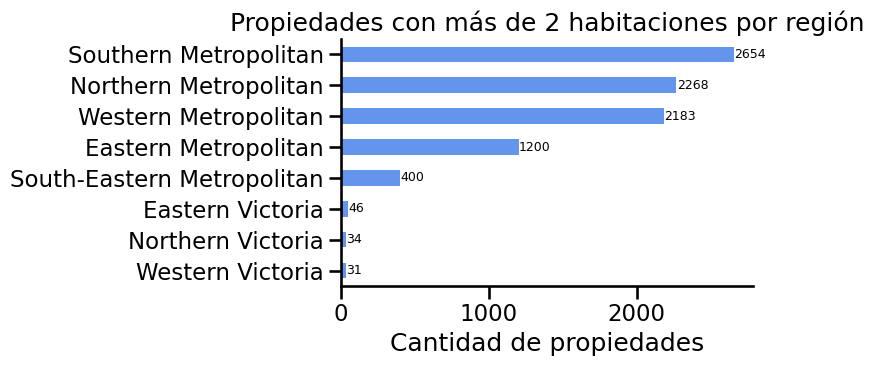

In [37]:
# Gráfico 3: Propiedades con más de 2 habitaciones por región
ax = resultado_q3.plot(
    kind='barh',
    x='Regionname',
    y='cantidad_propiedades_mas_2_rooms',
    color='cornflowerblue',
    legend=False,
    figsize=(8, 4)
)

plt.title('Propiedades con más de 2 habitaciones por región')
plt.xlabel('Cantidad de propiedades')
plt.ylabel('')
plt.gca().invert_yaxis()

ax.spines[['top', 'right']].set_visible(False)

for bar in plt.gca().patches:
    valor = bar.get_width()
    plt.gca().text(
        valor + 3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(valor)}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

El gráfico permite observar en qué regiones se concentra la mayor cantidad de propiedades con más de 2 habitaciones. Nuevamente, las regiones metropolitanas aparecen con mayor presencia, lo que sugiere una mayor disponibilidad de viviendas de tamaño medio o grande en esas zonas.

Este filtro permite diferenciar las propiedades más familiares o de mayor capacidad respecto de unidades más pequeñas. La distribución mantiene cierta relación con la cantidad total de registros por región, aunque ayuda a identificar específicamente dónde se concentran las propiedades con mayor cantidad de ambientes.

Las regiones con menor cantidad de registros también muestran menos propiedades con más de 2 habitaciones, por lo que su interpretación debe hacerse con cuidado.

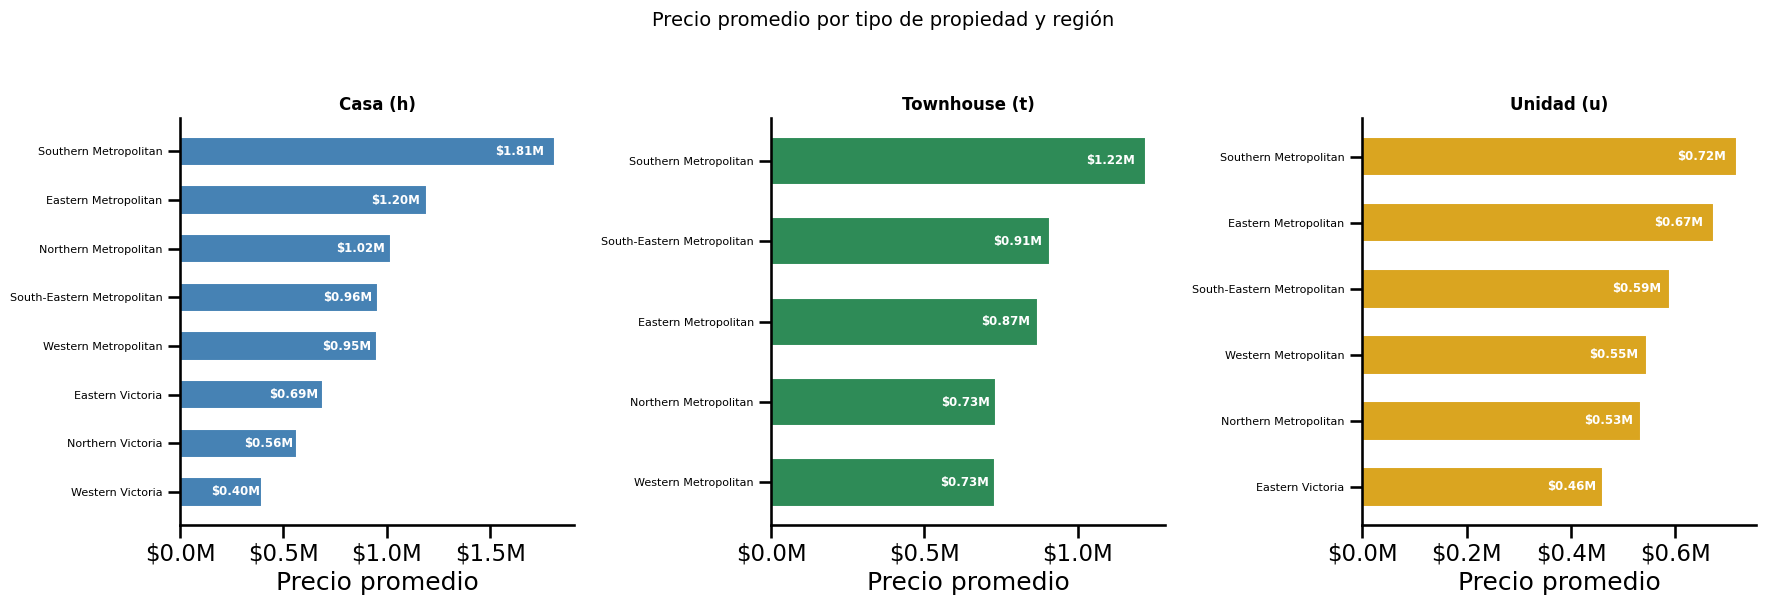

In [38]:
# Gráfico 4: Precio promedio por tipo de propiedad y región
millon_fmt = plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

tipos = {
    'h': 'Casa (h)',
    't': 'Townhouse (t)',
    'u': 'Unidad (u)'
}

colores = {
    'h': 'steelblue',
    't': 'seagreen',
    'u': 'goldenrod'
}

for ax, (tipo, label) in zip(axes, tipos.items()):
    subset = (
        resultado_q4[resultado_q4['Type'] == tipo]
        .sort_values('precio_promedio', ascending=True)
    )

    bars = ax.barh(
        subset['Regionname'],
        subset['precio_promedio'],
        color=colores[tipo],
        edgecolor='white',
        height=0.6
    )

    for bar, val in zip(bars, subset['precio_promedio']):
        ax.text(
            bar.get_width() * 0.97,
            bar.get_y() + bar.get_height() / 2,
            f'${val/1e6:.2f}M',
            va='center',
            ha='right',
            fontsize=8.5,
            color='white',
            fontweight='bold'
        )

    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Precio promedio')
    ax.xaxis.set_major_formatter(millon_fmt)
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Precio promedio por tipo de propiedad y región', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

El gráfico compara el precio promedio según el tipo de propiedad y la región. En general, las casas (h) presentan precios promedio más elevados que las townhouses (t) y las unidades (u), lo cual es esperable porque suelen tener mayor superficie, terreno y características residenciales más amplias.

También se observan diferencias importantes entre regiones. Algunas zonas metropolitanas presentan precios promedio más altos, lo que puede estar asociado a mayor demanda, mejor ubicación, cercanía a servicios o mayor valorización inmobiliaria.

Este análisis permite ver que el precio no depende solamente de la región, sino también del tipo de propiedad. Por eso, comparar precios promedio sin separar por Type podría ocultar diferencias relevantes entre casas, townhouses y unidades.

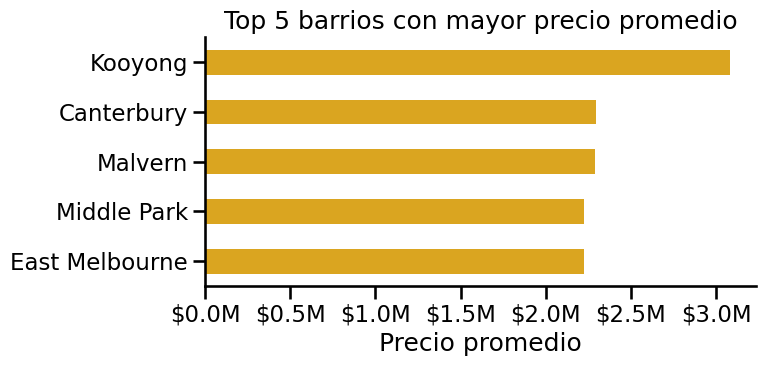

In [39]:
# Gráfico 5: Top 5 barrios con mayor precio promedio
ax = resultado_q5.plot(
    kind='barh',
    x='Suburb',
    y='precio_promedio',
    legend=False,
    color='goldenrod',
    figsize=(8, 4)
)

plt.title('Top 5 barrios con mayor precio promedio')
plt.xlabel('Precio promedio')
plt.ylabel('')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
)

ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

El gráfico muestra los cinco barrios con mayor precio promedio de propiedades. Estos barrios se ubican en la parte superior del ranking porque sus propiedades registran valores medios más altos dentro del dataset.

Sin embargo, para que el ranking sea más confiable, es importante considerar la cantidad de registros disponibles por barrio. Si un barrio tiene muy pocas propiedades, un solo valor extremo puede elevar artificialmente el promedio. Por eso, es recomendable utilizar una condición como 'HAVING COUNT(*)>=10'.

De esta manera, el ranking se calcula solo sobre barrios con una cantidad mínima de observaciones, reduciendo el riesgo de interpretar como caro un barrio que aparece arriba únicamente por pocos casos atípicos.

In [40]:
# Mapa: distribución geográfica del Top 5 de barrios más caros
top5_suburbs = resultado_q5['Suburb'].tolist()

data_top5 = melb_df[
    melb_df['Suburb'].isin(top5_suburbs)
].copy()

fig = px.scatter_mapbox(
    data_top5,
    lat="Lattitude",
    lon="Longtitude",
    color="Suburb",
    size="Price",
    size_max=25,
    opacity=0.7,
    hover_name="Address",
    hover_data={
        "Price": True,
        "Rooms": True,
        "Type": True,
        "Lattitude": False,
        "Longtitude": False
    },
    zoom=9,
    height=700,
    mapbox_style="open-street-map",
    title="Top 5 barrios más caros — distribución geográfica"
)

fig.update_layout(
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    mapbox_bounds={
        "west": data_top5.Longtitude.min() - 0.1,
        "east": data_top5.Longtitude.max() + 0.1,
        "south": data_top5.Lattitude.min() - 0.1,
        "north": data_top5.Lattitude.max() + 0.1
    }
)

fig.show()

El mapa permite visualizar la ubicación geográfica de las propiedades pertenecientes a los barrios con mayor precio promedio. Esta representación complementa el ranking anterior, porque no solo muestra cuáles son los barrios más caros, sino también dónde se localizan dentro del área de Melbourne.

La visualización geográfica ayuda a identificar si los barrios de mayor precio se encuentran concentrados en una zona específica o si están distribuidos en distintos sectores. Además, permite observar la relación entre ubicación, precio y concentración de propiedades.

### Unificación de datasets

#### Intersección de datos

Antes de unir los conjuntos de datos, nos aseguramos de tener suficientes registros en común para agregar información relevante.

In [41]:
# Exploramos valores en comun
intersection = np.intersect1d(
    airbnb_df['zipcode'].values, melb_df['Postcode'].values, assume_unique=False)

print("Airbnb unique zipcodes:", len(airbnb_df['zipcode'].unique()))
print("Sales unique zipcodes:", len(melb_df['Postcode'].unique()))
print("Common zipcodes:", len(intersection))
print('')

print('Registros en Melbourne con zipcode en Airbnb:',
      melb_df['Postcode'].isin(intersection).sum() / len(melb_df))
print('Registros en Airbnb con zipcode en Melbourne:',
      airbnb_df['zipcode'].isin(intersection).sum() / len(airbnb_df))

Airbnb unique zipcodes: 248
Sales unique zipcodes: 194
Common zipcodes: 188

Registros en Melbourne con zipcode en Airbnb: 0.9985993171671189
Registros en Airbnb con zipcode en Melbourne: 0.9029919196331077


#### Exploración visual

Para asegurarnos de que las áreas representadas por ambos datasets son consitentes, representamos las coordenadas en un mapa usando Plotly.

In [42]:
# Exploracion visual: Distirbucion geografica de ambos datasets

# Muestreo de Melbourne y conversión de SaleYear a string (categórico)
data_melb = melb_df.sample(300, random_state=42).copy()
data_melb['SaleYear'] = data_melb['SaleYear'].astype(str)

# Limpieza y filtrado de Airbnb
airbnb_df['state_clean'] = airbnb_df['state'].str.strip().str.upper()
airbnb_df['state_clean'] = airbnb_df['state_clean'].replace({
    'VI': 'VIC',
    'VICTORIA': 'VIC',
    '維多利亞 VIC': 'VIC'
})
# Filtramos para asegurarnos de que solo graficamos la zona de interés (VIC)
data_airbnb = airbnb_df[airbnb_df['state_clean'] == 'VIC'].sample(300, random_state=42)


# CONSTRUCCIÓN DEL MAPA UNIFICADO

fig = go.Figure()

# Capa 1: Propiedades en Venta (Melbourne)
# Usamos un bucle para separar por año de venta y evitar el gradiente continuo
for year in sorted(data_melb['SaleYear'].unique()):
    df_year = data_melb[data_melb['SaleYear'] == year]

    fig.add_trace(go.Scattermapbox(
        lat=df_year['Lattitude'],
        lon=df_year['Longtitude'],
        mode='markers',
        marker=dict(
            size=8,
            opacity=0.7
        ),
        name=f'Venta Melb - {year}',
        text=df_year.apply(lambda r: f"Precio: ${r['Price']:,.0f}<br>Tipo: {r['Type']}<br>Barrio: {r['Suburb']}", axis=1),
        hoverinfo='text'
    ))

# Capa 2: Listings de Airbnb
fig.add_trace(go.Scattermapbox(
    lat=data_airbnb['latitude'],
    lon=data_airbnb['longitude'],
    mode='markers',
    marker=dict(
        size=6,
        color='gold', # Color fijo contrastante para diferenciarlo de las ventas
        opacity=0.6
    ),
    name='Airbnb Listings',
    text=data_airbnb.apply(lambda r: f"Precio/Noche: ${r['price']}<br>Barrio: {r['neighborhood']}", axis=1),
    hoverinfo='text'
))


# DISEÑO Y CONFIGURACIÓN DEL LAYOUT

# Calculamos el centro dinámico del mapa basado en los datos de Melbourne
center_lat = data_melb['Lattitude'].median()
center_lon = data_melb['Longtitude'].median()

fig.update_layout(
    title={
        'text': "<b>Análisis Inmobiliario en Melbourne: Ventas vs. Airbnb</b>",
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    mapbox=dict(
        style='open-street-map',
        center=dict(lat=center_lat, lon=center_lon),
        zoom=9.5
    ),
    margin={"r": 10, "t": 60, "l": 10, "b": 10},
    height=650,
    legend=dict(
        title_text="<b>Capas de Datos</b>",
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor="rgba(255, 255, 255, 0.8)" # Fondo semi-transparente para legibilidad
    )
)

fig.show()

#### Agrupación y unificación

Se renombran y agrupan las columnas de `airbnb_df` por zipcode usando diccionarios, cuyas *keys* son las columnas originales por agregar y los *values* son las operaciones.

In [43]:
# Verificacion de columnas contenidas en airbnb
airbnb_price_by_zipcode.columns

Index(['zipcode', 'airbnb_price_median', 'airbnb_record_count',
       'airbnb_weekly_price_median', 'airbnb_monthly_price_median'],
      dtype='object')

In [44]:
airbnb_price_by_zipcode[:3]

,zipcode,airbnb_price_median,airbnb_record_count,airbnb_weekly_price_median,airbnb_monthly_price_median
0,0,120.0,146,780.0,3300.0
1,2010,40.0,1,NaN,NaN
2,2134,50.0,1,NaN,NaN


In [45]:
# Guardado del dataset en formato .csv
airbnb_price_by_zipcode.to_csv("airbnb_price_by_zipcode.csv", index=None)

In [46]:
# Unificacion del dataset de Melbourne con el de airbnb agrupado por zipcode
merged_sales_df = melb_df.merge(
    airbnb_price_by_zipcode, how='left',
    left_on='Postcode', right_on='zipcode'
)
merged_sales_df.sample(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Distance,Postcode,Bathroom,...,Longtitude,Regionname,Propertycount,SaleYear,SaleMonth,zipcode,airbnb_price_median,airbnb_record_count,airbnb_weekly_price_median,airbnb_monthly_price_median
58,Airport West,105a Victory Rd,3,h,612000.0,S,Nelson,13.5,3042,2,...,144.88240,Western Metropolitan,3464,2016,8,3042.0,65.0,35.0,400.0,1550.0
1780,Coburg North,45 Shorts Rd,3,h,720000.0,S,Nelson,9.2,3058,1,...,144.95760,Northern Metropolitan,3445,2016,7,3058.0,75.0,133.0,430.0,1700.0
7025,Brighton,36/568 New St,1,u,380000.0,VB,Chisholm,10.5,3186,1,...,144.99722,Southern Metropolitan,10579,2017,7,3186.0,159.5,124.0,900.0,3550.0
7775,Hoppers Crossing,2 Bowden St,3,h,555000.0,S,hockingstuart,18.4,3029,2,...,144.69959,Western Metropolitan,13830,2017,6,3029.0,58.0,113.0,350.0,1200.0
11124,Port Melbourne,136 Clark St,3,h,1725000.0,PI,Marshall,3.5,3207,1,...,144.93586,Southern Metropolitan,8648,2017,9,3207.0,152.0,257.0,1100.0,3600.0


In [47]:
merged_sales_df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Distance', 'Postcode', 'Bathroom', 'Car', 'Landsize', 'CouncilArea',
       'Lattitude', 'Longtitude', 'Regionname', 'Propertycount', 'SaleYear',
       'SaleMonth', 'zipcode', 'airbnb_price_median', 'airbnb_record_count',
       'airbnb_weekly_price_median', 'airbnb_monthly_price_median'],
      dtype='object')

#### Validación

Se chequea que la cantidad de filas se mantuvo y que no aparecieron nulos inesperados en las columnas agregadas.

Se validan dimensiones básicas de calidad de datos:

- validez,
- completitud,
- integridad.

In [48]:
print(f"Filas antes: {len(melb_df)}")
print(f"Filas después: {len(merged_sales_df)}")
print(f"Nulls nuevos en airbnb_price_median: {merged_sales_df['airbnb_price_median'].isna().sum()}")

assert len(merged_sales_df) == len(melb_df), "El merge cambió el número de filas"
assert merged_sales_df["Price"].isna().sum() == 0, "Hay nulls inesperados en Price"
assert merged_sales_df["airbnb_price_median"].dropna().between(0, 10000).all(), "Precios fuera de rango"

Filas antes: 11423
Filas después: 11423
Nulls nuevos en airbnb_price_median: 16


In [49]:
merged_sales_df.to_csv("melb_data_extended.csv", index=None)

## Ejercicio 2 - Pandas:

Este ejercicio usa el archivo `airbnb_price_by_zipcode.csv` generado en el notebook `02.1 Combinación de datasets.ipynb`. Si no lo tenés, generarlo primero antes de comenzar esta parte.

1. Seleccionar un subconjunto de columnas que les parezcan relevantes al problema de predicción del valor de la propiedad. Justificar explicitamente las columnas seleccionadas y las que no lo fueron.
  1. Valores faltantes: ¿Qué porcentaje de filas tienen al menos un valor faltante?
  2. Mostrar la dispersión o distribución de las columnas seleccionadas.
 3. Eliminar los valores extremos que no sean relevantes para la predicción de valores de las propiedades.
 4. Mostrar visualmente los valores extremos que eliminás


2. Agregar información adicional respectiva al entorno de una propiedad a partir del [conjunto de datos de AirBnB](https://www.kaggle.com/tylerx/melbourne-airbnb-open-data?select=cleansed_listings_dec18.csv) utilizado en el práctico.
  1. Seleccionar qué variables agregar y qué combinaciones aplicar a cada una. Por ejemplo, pueden utilizar solo la columna `price`, o aplicar múltiples transformaciones como la mediana (¿por qué no la media?) o el mínimo.
  2. Utilizar la variable zipcode para unir los conjuntos de datos. Sólo incluir los zipcodes que tengan una cantidad mínima de registros (a elección) como para que la información agregada sea relevante.
  3. Mostrar un gráfico zipcode vs airbnb_price_median.
  4. Investigar al menos otras 2 variables que puedan servir para combinar los datos, y justificar si serían adecuadas o no. Pueden asumir que cuentan con la ayuda de anotadores expertos para encontrar equivalencias entre barrios o direcciones, o que cuentan con algoritmos para encontrar las n ubicaciones más cercanas a una propiedad a partir de sus coordenadas geográficas. **NO** es necesario que realicen la implementación. Si tuvieras que entrevistar a un experto inmobiliario para mapear barrios entre datasets, ¿qué 3 preguntas le harías para validar esa correspondencia?
  5. Si las coordenadas geoespaciales estuvieran disponibles, como las usarian?

Pueden leer otras columnas del conjunto de AirBnB además de las que están en `interesting_cols`, si les parecen relevantes.

¿Qué cosas no están en los datos que te gustaría tener para predecir mejor el precio de una propiedad?


### Criterios de evaluación
Se evaluará principalmente:
- claridad del código,
- justificación de las decisiones de curación,
- coherencia entre el análisis realizado y las conclusiones,
- presencia de validaciones después de operaciones críticas como merges o cargas a base.

No se espera una única solución correcta, pero sí que las decisiones estén justificadas y sean consistentes con los datos.


In [50]:
airbnb_price_by_zipcode.columns

Index(['zipcode', 'airbnb_price_median', 'airbnb_record_count',
       'airbnb_weekly_price_median', 'airbnb_monthly_price_median'],
      dtype='object')

In [51]:
airbnb_price_by_zipcode.head()

,zipcode,airbnb_price_median,airbnb_record_count,airbnb_weekly_price_median,airbnb_monthly_price_median
0,0,120.0,146,780.0,3300.0
1,2010,40.0,1,NaN,NaN
2,2134,50.0,1,NaN,NaN
3,2582,104.0,1,NaN,NaN
4,3000,129.0,3367,857.0,3469.0


### 2.1 Selección de columnas relevantes


In [52]:
airbnb_price_by_zipcode.describe()

,zipcode,airbnb_price_median,airbnb_record_count,airbnb_weekly_price_median,airbnb_monthly_price_median
count,248.000000,248.000000,248.000000,185.000000,169.000000
mean,3494.391129,110.102823,92.318548,651.200000,2475.079882
std,1913.073652,60.562633,261.406379,343.193812,1496.435722
min,0.000000,37.000000,1.000000,133.000000,527.000000
25%,3071.750000,68.875000,8.750000,385.000000,1490.000000
50%,3147.500000,92.000000,27.000000,600.000000,2200.000000
75%,3509.250000,133.875000,74.000000,815.000000,3004.000000
max,30122.000000,317.000000,3367.000000,2000.000000,10060.000000


In [53]:
merged_sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11423 entries, 0 to 11422
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Suburb                       11423 non-null  object 
 1   Address                      11423 non-null  object 
 2   Rooms                        11423 non-null  int64  
 3   Type                         11423 non-null  object 
 4   Price                        11423 non-null  float64
 5   Method                       11423 non-null  object 
 6   SellerG                      11423 non-null  object 
 7   Distance                     11423 non-null  float64
 8   Postcode                     11423 non-null  int64  
 9   Bathroom                     11423 non-null  int64  
 10  Car                          11423 non-null  int64  
 11  Landsize                     11423 non-null  float64
 12  CouncilArea                  11423 non-null  object 
 13  Lattitude       

Se utilizaron dos criterios para seleccionar las columnas:


###**Criterio 1 - Correlación lineal (variables numéricas)**:

Calculamos la correlación de Pearson como punto de partida exploratorio para entender la relación lineal de cada variable con el precio. Sin embargo, la selección final integra también conocimiento de dominio, ya que Pearson tiene limitaciones en no contemplar relaciones no lineales, no aplica a categóricas y una baja correlación lineal no implica irrelevancia predictiva.

Se toma el dataset con todos los valores incorporados y se calcula la correlación de cada variable numérica con Price. El gráfico de correlaciones y el umbral de 0.2 se usan como guía exploratoria para identificar variables con relación lineal más clara. Las variables por debajo del umbral no se descartan automáticamente, cada uno se evalúa además con criterio de dominio para decidir si se incluye o no.



 melb_numeric datos: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11423 entries, 0 to 11422
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rooms                        11423 non-null  int64  
 1   Price                        11423 non-null  float64
 2   Distance                     11423 non-null  float64
 3   Postcode                     11423 non-null  int64  
 4   Bathroom                     11423 non-null  int64  
 5   Car                          11423 non-null  int64  
 6   Landsize                     11423 non-null  float64
 7   Lattitude                    11423 non-null  float64
 8   Longtitude                   11423 non-null  float64
 9   Propertycount                11423 non-null  int64  
 10  SaleYear                     11423 non-null  int32  
 11  SaleMonth                    11423 non-null  int32  
 12  zipcode                      11407 non-null  float

/tmp/ipykernel_4802/3410237651.py:39: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




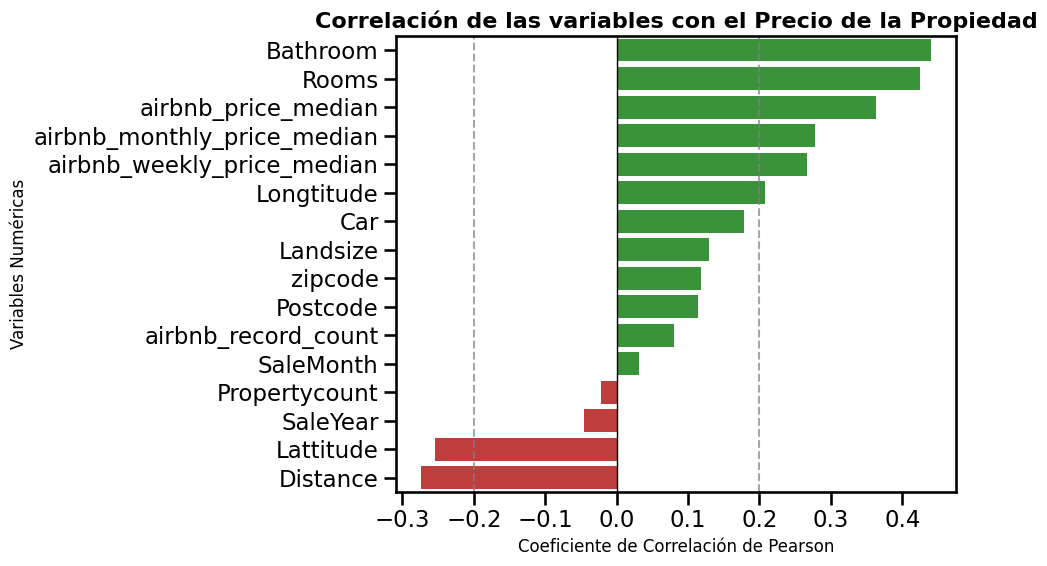


Columnas seleccionadas con correlación absoluta mayor o igual a 0.2:
['Bathroom', 'Rooms', 'airbnb_price_median', 'airbnb_monthly_price_median', 'airbnb_weekly_price_median', 'Longtitude', 'Lattitude', 'Distance', 'Price']


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Asegurar que los valores numéricos lo sean
# Lista de columnas que por naturaleza de este conjunto de datos deberían ser numéricas
cols_to_numeric = ['Rooms', 'Price', 'Distance', 'Postcode', 'Bathroom',
                   'Car', 'Landsize', 'Propertycount', 'SaleYear', 'Lattitude', 'Longtitude',
                   'SaleMonth', 'zipcode', 'airbnb_price_median',
                   'airbnb_record_count', 'airbnb_weekly_price_median', 'airbnb_monthly_price_median']

# Forzamos la conversión a numérico. Los valores ilegibles se convertirán en NaN (errors='coerce')
for col in cols_to_numeric:
    if col in merged_sales_df.columns:
        merged_sales_df[col] = pd.to_numeric(merged_sales_df[col], errors='coerce')

# Filtramos solo las columnas numéricas para evitar errores en la matriz de correlación
melb_numeric = merged_sales_df.select_dtypes(include=['number', 'float64', 'int64']).copy()

# Eliminamos filas donde el precio es nulo, ya que no nos sirven para calcular correlación
melb_numeric = melb_numeric.dropna(subset=['Price'])
print ("\n melb_numeric datos: \n")
melb_numeric.info()


# 3. Calcular los coeficientes de correlación
correlaciones = melb_numeric.corr()

# Aislamos la columna 'Price', quitamos la auto-correlación (Price vs Price = 1) y ordenamos
corr_con_precio = correlaciones['Price'].drop('Price').sort_values(ascending=False)

# 4. Generar el gráfico de coeficientes
plt.figure(figsize=(10, 6))

# Asignamos colores: un color para correlación positiva y otro para negativa
colores = ['#2ca02c' if valor > 0 else '#d62728' for valor in corr_con_precio.values]

sns.barplot(x=corr_con_precio.values, y=corr_con_precio.index, palette=colores)

# Configuración estética del gráfico
plt.title('Correlación de las variables con el Precio de la Propiedad', fontsize=16, fontweight='bold')
plt.xlabel('Coeficiente de Correlación de Pearson', fontsize=12)
plt.ylabel('Variables Numéricas', fontsize=12)

# Línea central en cero
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)

# Líneas guía de umbral (ej. 0.2 y -0.2) para ayudar a decidir qué descartar
umbral_visual = 0.2
plt.axvline(x=umbral_visual, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axvline(x=-umbral_visual, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

plt.tight_layout()
plt.show()

# 5. Selección final de columnas
# Seleccionamos automáticamente aquellas que superan el umbral (ya sea positivo o negativo)
columnas_seleccionadas = corr_con_precio[abs(corr_con_precio) >= umbral_visual].index.tolist()

# Agregamos 'Price' de vuelta a la lista, ya que es nuestro target
columnas_seleccionadas.append('Price')

print(f"\nColumnas seleccionadas con correlación absoluta mayor o igual a {umbral_visual}:")
print(columnas_seleccionadas)

# Si deseas aplicar esta selección al DataFrame original:
# melb_df_final = melb_df[columnas_seleccionadas]

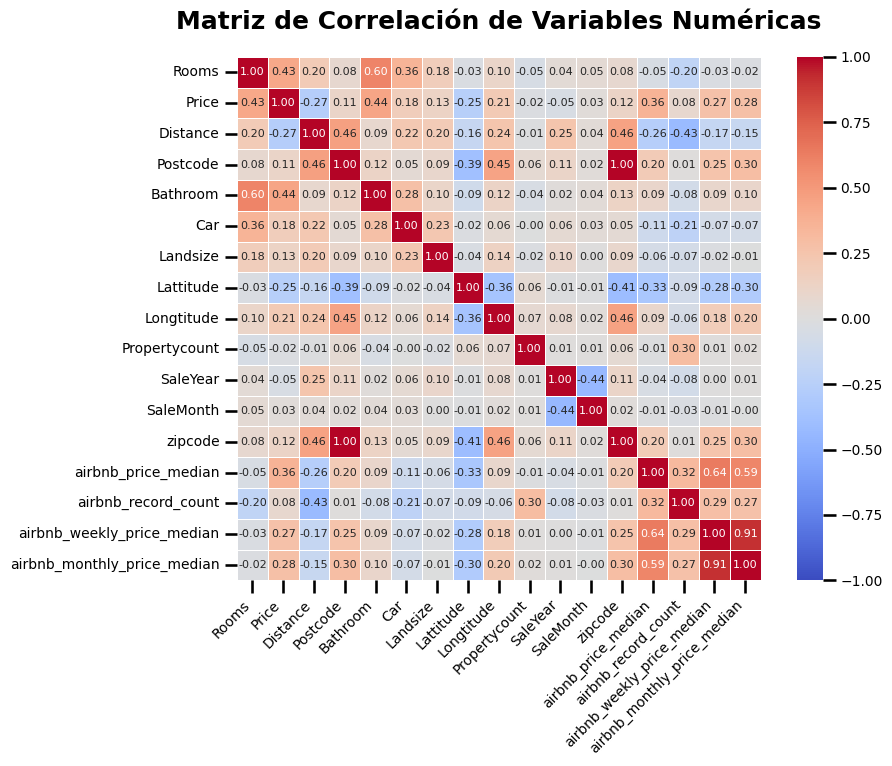

In [55]:
# 6. Generar la matriz de Heatmap para todas las variables
plt.figure(figsize=(10, 8))

# Creamos el heatmap
ax =sns.heatmap(
    correlaciones,
    annot=True,          # Muestra los valores numéricos de correlación en cada celda
    annot_kws={"size": 8},
    fmt=".2f",           # Formatea los números a 2 decimales para mayor legibilidad
    cmap="coolwarm",     # Paleta de colores divergente (rojo para +, azul para -)
    vmin=-1, vmax=1,     # Fija los límites de la escala de colores de -1 a 1
    center=0,            # Centra el color blanco/neutro en el 0
    linewidths=0.5,      # Agrega una pequeña línea de separación entre celdas
    square=True          # Fuerza que las celdas sean cuadradas
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)

# Configuración estética
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()


In [56]:
print (corr_con_precio.items())

In [57]:
columnas_seleccionadas = []

for columna, valor_corr in corr_con_precio.items():

    # if abs(valor_corr) > 2e-1:   En caso de usar las correlaciones que afectan de forma inversa al precio reemplazar por este if la línea siguiente
    if valor_corr > 2e-1:
        columnas_seleccionadas.append(columna)

if 'Price' not in columnas_seleccionadas:
    columnas_seleccionadas.append('Price')

print("Columnas con correlación absoluta mayor a 0.2:")
print(columnas_seleccionadas)

Columnas con correlación absoluta mayor a 0.2:
['Bathroom', 'Rooms', 'airbnb_price_median', 'airbnb_monthly_price_median', 'airbnb_weekly_price_median', 'Longtitude', 'Price']


In [58]:
print(corr_con_precio.sort_values())

Distance                      -0.273354
Lattitude                     -0.254868
SaleYear                      -0.045959
Propertycount                 -0.021783
SaleMonth                      0.030999
airbnb_record_count            0.080181
Postcode                       0.114632
zipcode                        0.117876
Landsize                       0.129347
Car                            0.178771
Longtitude                     0.207701
airbnb_weekly_price_median     0.266131
airbnb_monthly_price_median    0.277937
airbnb_price_median            0.362985
Rooms                          0.425211
Bathroom                       0.439715
Name: Price, dtype: float64


Como se mencionó anteriormente, la correlación de Pearson se usó como herramienta exploratoria para entender la relación lineal de cada variable con el precio, no como criterio de corte automático.

Se observa que variables como Car o Landsize muestran correlación lineal baja porque su relación con el precio está mediada por la ubicación, un terreno grande en zona periférica vale menos que uno chico en zona premium, esto disminuye a la correlación global pero no invalida la variable como predictor. La selección final se basa en criterio de dominio inmobiliario, donde características físicas, ubicación y contexto temporal son los tres ejes explicativos del precio.

**Variables seleccionadas y sus correlaciones:**



*  Bathroom (0,44) y Rooms (0,43): características físicas directas de la propiedad, más ambientes implican mayor superficie y confort, determinantes directos del valor de mercado.
*  airbnb_price_median (0,36): es la variable de Airbnb con mayor correlación con Price y se incluye como indicador del atractivo del zipcode. Las variables airbnb_weekly_price_median y airbnb_monthly_price_median se excluyen porque tienen una correlación de 0.91 entre ellas, lo que implica multicolinealidad: están aportando casi la misma información. Incluir las tres haría redundante la representación del entorno Airbnb.
*   Distance (-0,27): a mayor distancia del CBD, menor precio. Correlación negativa pero con sentido inmobiliario claro. Se incluye a pesar del signo negativo porque lo relevante es la magnitud de la relación, no su dirección.
*  Lattitude (-0,25) y Longitude (0,21): captura patrones espaciales de precio que Distance sola no refleja.





**Variables incluídas por criterio de dominio a pesar de baja correlación lineal** (corr < 0,2):

- Car (0,18): aunque queda levemente debajo del umbral, la disponibilidad de cochera propia es una característica con valor de mercado directo, especialmente en zonas donde el estacionamiento es escaso. Su baja correlación lineal se explica porque la relación con el precio está mediada por la ubicación, en las que las zonas céntricas suelen tener menos cocheras que zonas periféricas más baratas.

- Landsize (0,13): el tamaño del terreno es un determinante del valor que ningún modelo inmobiliario ignoraría. La correlación lineal baja refleja una relación no lineal con el precio, indicando que un terreno grande en zona periférica vale menos que uno chico en zona premium, pero eso no invalida su relevancia predictiva.

- SaleYear (-0,05) y SaleMonth (0,03): la correlación lineal es baja porque el período analizado cubre solo 2016-2017. Sin embargo, se incluyen porque el mercado inmobiliario tiene variaciones estacionales y anuales reales.


**Variables excluídas por correlación baja sin argumento de dominio**

- Postcode y zipcode (0,11 y 0,12): son identificadores geográficos utilizados como clave de join entre datasets. Su información queda representada por las variables de AirBnB agregadas por zipcode.

Aclaración: Postcode  se conserva en el dataframe para el análisis del punto 2.3 (gráfico zipcode vs airbnb_price_median), pero no se considera una feature predictora.

-  airbnb_record_count (0,08): indicador de densidad de datos AirBnB por zipcode,
  no del valor de la propiedad.
- Propertycount (-0,02): característica del suburbio, no de la propiedad individual.


###**Criterio 2: Relevancia de dominio (variables categóricas):**


Sabiendo que Pearson no aplica a categóricas, se evalúan por criterio de dominio. Un factor adicional es la cardinalidad: variables con muchas categorías únicas generan bases muy amplias si se aplica one-hot encoding, lo que puede dificultar el entrenamiento de modelos. Por eso se priorizan variables con cardinalidad manejable o alto valor informativo.

Se analiza la cardinalidad de las variables categóricas disponibles:

In [59]:
# Análisis de cardinalidad de variables categóricas
cat_cols = ['Type', 'Suburb', 'Regionname', 'Method', 'SellerG', 'CouncilArea', 'Address']
for col in cat_cols:
    if col in merged_sales_df.columns:
        card = merged_sales_df[col].nunique()
        print(f"{col}: {card} categorías únicas")

Type: 3 categorías únicas
Suburb: 309 categorías únicas
Regionname: 8 categorías únicas
Method: 5 categorías únicas
SellerG: 251 categorías únicas
CouncilArea: 34 categorías únicas
Address: 11250 categorías únicas


En base a la cardinalidad y el significado inmobiliario de cada variable:

**Incluídas**:
- Type (3 categorías): el tipo de propiedad (casa, unidad, townhouse) es determinante directo del precio.
- Suburb (309 categorías): granularidad fina de ubicación. Cardinalidad alta pero su valor predictivo justifica incluirla, en modelos se puede usar targen encoding en lugar de one-hot.

**Excluidas:**
- Regionname (8 categorías): su información queda contenida dentro de Suburb, cada suburbio pertenece a una región, por lo que el modelo puede aprender esa relación directamente desde Suburb. Se excluye para reducir la dimensionalidad.
- Method (5 categorías): describe el proceso de venta, no  un atributo de la propiedad.
- SellerG (251 categorías): identifica a la inmobiliaria vendedora, cardinalidad muy alta que generaría una base enorme.
- CouncilArea (30 categorías): redundante con Suburb y Regionname, y con valores imputados como 'Desconocido' desde la limpieza del Ejercicio 1.
- Address (único por fila): identificador único sin poder predictivo generalizable.

In [60]:
umbral = 0.2

# Criterio 1: correlación lineal con valor absoluto >= umbral
columnas_por_correlacion = corr_con_precio[abs(corr_con_precio) >= umbral].index.tolist()

# Excluir variables Airbnb redundantes
# Se conserva solo airbnb_price_median
columnas_por_correlacion = [c for c in columnas_por_correlacion
                             if c not in ['airbnb_weekly_price_median',
                                          'airbnb_monthly_price_median']]

# Criterio 1b: incluidas por criterio de dominio a pesar de correlación baja
columnas_por_dominio_numerico = ['Car', 'Landsize', 'SaleYear', 'SaleMonth']

# Criterio 2: categóricas relevantes por dominio (Pearson no aplica a categóricas)
columnas_categoricas = ['Type', 'Suburb']

# Postcode se conserva para el gráfico del punto 2.3, no es feature predictora
columnas_para_graficos = ['Postcode']


columnas_finales = list(dict.fromkeys(
    columnas_por_correlacion
    + columnas_por_dominio_numerico
    + columnas_categoricas
    + columnas_para_graficos
))

if 'Price' not in columnas_finales:
    columnas_finales.append('Price')

print("Por correlación (|corr| >= 0.2), excluyendo redundantes Airbnb:")
print(columnas_por_correlacion)
print("\nPor dominio numérico (correlación baja pero relevantes):")
print(columnas_por_dominio_numerico)
print("\nPor relevancia de dominio (categóricas):")
print(columnas_categoricas)
print("\nConservadas para análisis (no features):")
print(columnas_para_graficos)
print("\nExcluidas por multicolinealidad:")
print(['airbnb_weekly_price_median', 'airbnb_monthly_price_median'])
print(f"\nTotal: {len(columnas_finales)} columnas")

melb_seleccionado = merged_sales_df[columnas_finales].copy()
print(f"Shape del dataset: {melb_seleccionado.shape}")

Por correlación (|corr| >= 0.2), excluyendo redundantes Airbnb:
['Bathroom', 'Rooms', 'airbnb_price_median', 'Longtitude', 'Lattitude', 'Distance']

Por dominio numérico (correlación baja pero relevantes):
['Car', 'Landsize', 'SaleYear', 'SaleMonth']

Por relevancia de dominio (categóricas):
['Type', 'Suburb']

Conservadas para análisis (no features):
['Postcode']

Excluidas por multicolinealidad:
['airbnb_weekly_price_median', 'airbnb_monthly_price_median']

Total: 14 columnas
Shape del dataset: (11423, 14)


### Resumen de lo obtenido

El dataset melb_seleccionado quedó conformado por 14 columnas y 11423 filas.
La selección combina dos criterios complementarios:

- Correlación de Pearson como herramienta exploratoria para variables numéricas: se retuvieron aquellas con cor| >= 0.2 respecto a Price. Dentro de las variables  que superaban el umbral, se excluyeron airbnb_weekly_price_median y airbnb_monthly_price_median por presentar una correlación de 0,91 entre sí, conservando únicamente airbnb_price_median por ser la que  mayor correlación tiene con Price (0,36).
- Criterio de dominio para incluir variables con correlación baja pero relevancia inmobiliaria clara (Car, Landsize, SaleYear, SaleMonth) y para incorporar las categóricas Type y Suburb, a las que Pearson no aplica, y para excluir categóricas con cardinalidad muy alta como SellerG o Address que generarían una base muy amplia  ante un eventual one-hot encoding.

Postcode se conserva únicamente para el gráfico del punto 2.3, sin considerarse feature predictora.

### 2.2. % de filas con al menos un valor faltante

In [61]:
filas_con_nulos = melb_seleccionado.isnull().any(axis=1).sum()
total = len(melb_seleccionado)
pct = filas_con_nulos / total

print(f"Filas con al menos un nulo: {filas_con_nulos} ({pct:.1%})")
print(f"\nNulos por columna:")
print(melb_seleccionado.isnull().sum()[melb_seleccionado.isnull().sum() > 0].sort_values(ascending=False))

Filas con al menos un nulo: 16 (0.1%)

Nulos por columna:
airbnb_price_median    16
dtype: int64


Solo el 0,1% de las filas (16 registros) tiene al menos un valor faltante,  concentrados únicamente en airbnb_price_median .

Las variables airbnb_weekly_price_median y airbnb_monthly_price_median
ya fueron excluidas en la selección
de columnas por su alta correlación entre sí que introducía multicolinealidad.

Las variables del dataset de Melbourne (Rooms, Price, Bathroom, Landsize, etc.)
no presentan nulos, lo que valida la curación realizada en el Ej 1.

Estos 16 nulos en airbnb_price_median corresponden a zipcodes sin actividad  registrada en Airbnb y se tratarán en el punto 2.7 al filtrar por mínimo de registros.





### 2.3. Distribución de columnas seleccionadas y exploración de outliers

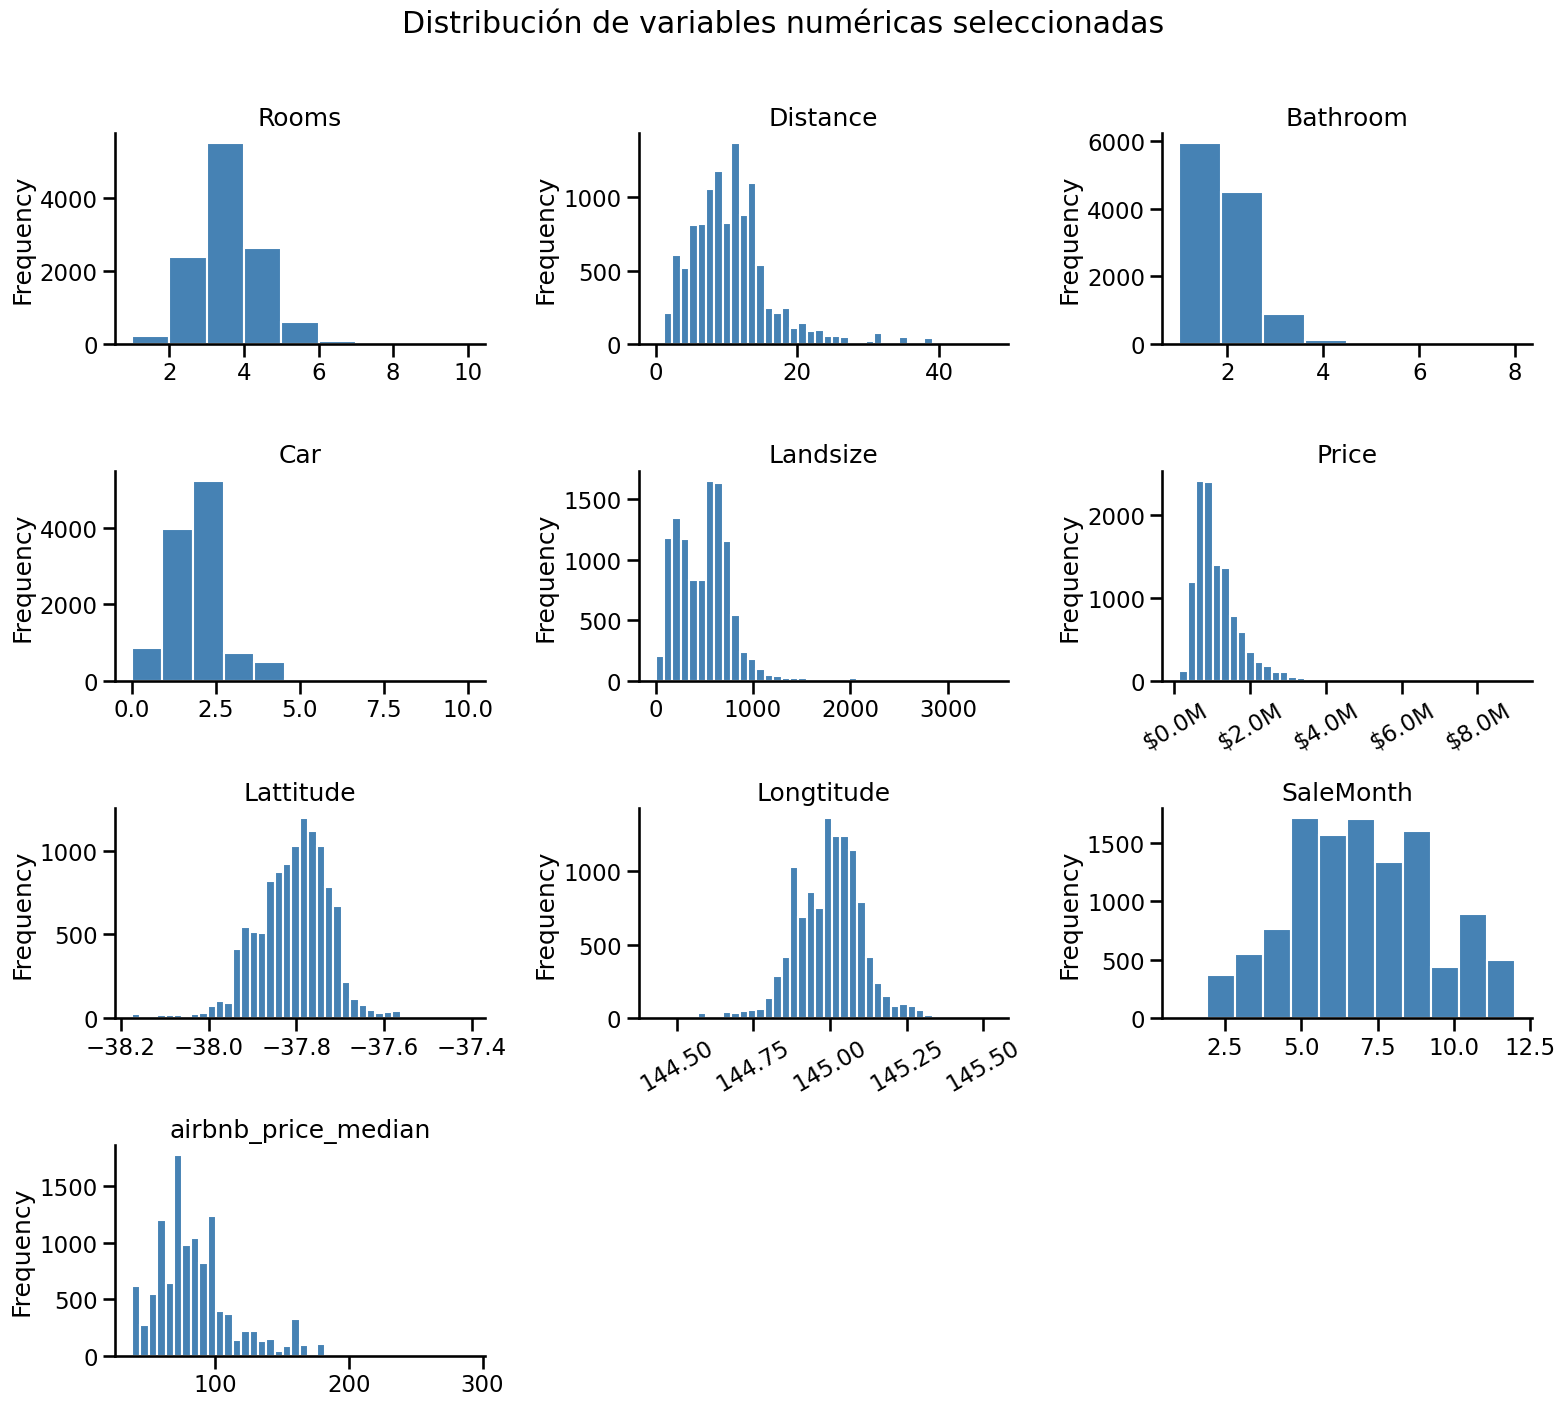

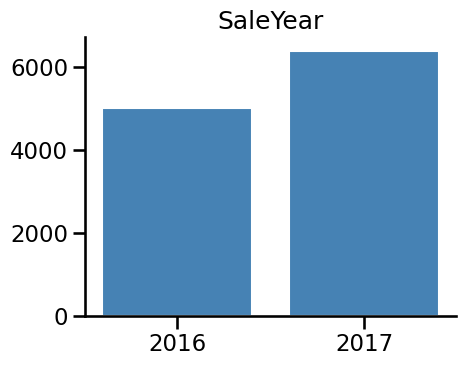

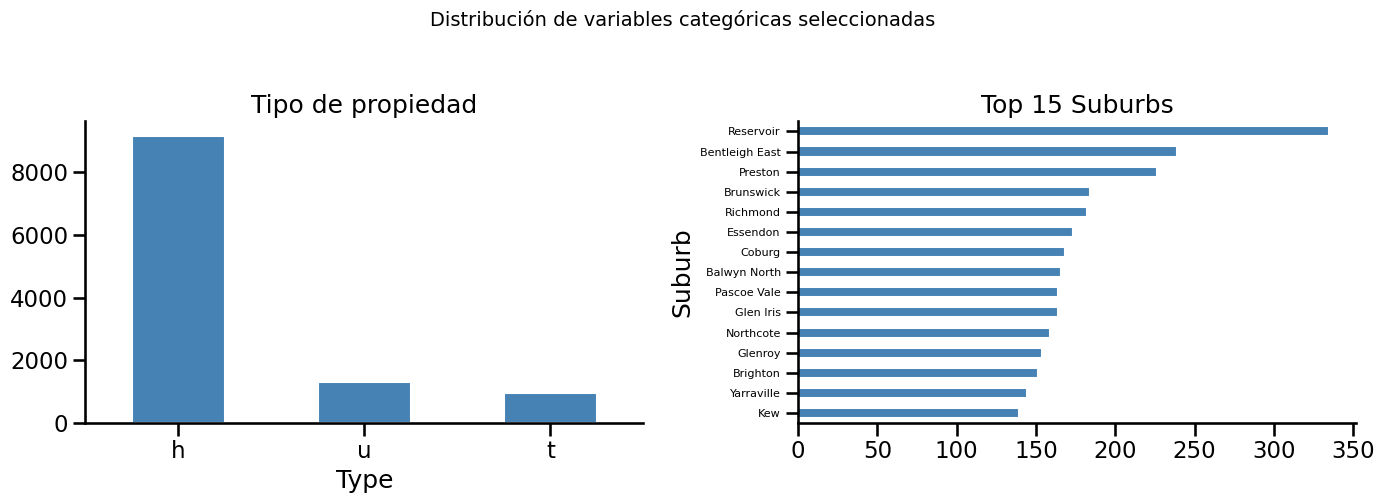

In [62]:
# Numéricas
num_cols_continuas = ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'Price',
                      'Lattitude', 'Longtitude', 'SaleMonth', 'airbnb_price_median']

fig, axes = plt.subplots(4, 3, figsize=(16, 14))  # 10 vars + 2 celdas vacías
axes = axes.flatten()

for i, col in enumerate(num_cols_continuas):
    n_unique = melb_seleccionado[col].nunique()
    bins = min(n_unique, 40)
    melb_seleccionado[col].dropna().plot(
        kind='hist', bins=bins, ax=axes[i],
        color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].spines[['top', 'right']].set_visible(False)
    if col == 'Price':
        axes[i].xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
        axes[i].tick_params(axis='x', rotation=30)
    if col == 'Longtitude':
        axes[i].xaxis.set_major_locator(plt.MaxNLocator(5))
        axes[i].tick_params(axis='x', rotation=30)

for j in range(len(num_cols_continuas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas seleccionadas', y=1.01)
plt.tight_layout()
plt.show()

# SaleYear como categórica
fig, ax = plt.subplots(figsize=(5, 4))
sale_year_counts = melb_seleccionado['SaleYear'].value_counts().sort_index()
ax.bar(sale_year_counts.index.astype(str), sale_year_counts.values,
       color='steelblue', edgecolor='white')
ax.set_title('SaleYear')
ax.set_xlabel('')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Categóricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de variables categóricas seleccionadas', fontsize=14, y=1.02)

melb_seleccionado['Type'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Tipo de propiedad')
axes[0].tick_params(axis='x', rotation=0)
axes[0].spines[['top', 'right']].set_visible(False)

melb_seleccionado['Suburb'].value_counts().head(15).plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Top 15 Suburbs')
axes[1].invert_yaxis()
axes[1].tick_params(axis='y', labelsize=8)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


**Análisis de distribuciones:**

- Rooms: distribución concentrada en 2–4 ambientes, el mercado está dominado por propiedades medianas.
- Distance: distribución sesgada a la derecha con la mayoría entre 5–15 km del CBD. Pocas propiedades superan los 30 km.
- Bathroom: la gran mayoría tiene 1–2 baños. Valores mayores a 3 son casos atípicos.
- Car: concentrado en 1–2 cocheras, con algunos casos sin cochera.
- Landsize: distribución muy sesgada a la derecha. La mayoría de las propiedades tiene entre 200–1000 m², con una cola larga que indica valores extremos aún presentes.
- Price: distribución sesgada a la derecha con la mayoría entre 0.5M y 2M AUD. La cola derecha refleja propiedades de lujo, lo que justifica el uso de la mediana como medida de tendencia central en lugar de la media.
- Lattitude / Longtitude: distribuciones concentradas que reflejan el área metropolitana de Melbourne.
- SaleYear: el dataset cubre 2016 y 2017, con mayor cantidad de ventas registradas en 2017.
- SaleMonth: las ventas se distribuyen a lo largo del año con mayor actividad entre los meses 4–11.
- airbnb_price_median: distribución sesgada a la derecha concentrada entre 50-150 AUD/noche, con cola hacia valores más costosos.
- Type: las casas (`h`) dominan ampliamente, seguidas de unidades (`u`) y townhouses (`t`).
- Suburb: Reservoir lidera con aproximadamente 340 propiedades, seguido de Bentleigh East y Preston. La distribución entre suburbs es relativamente uniforme a partir del top 4.

Los boxplots permiten identificar visualmente que variables tienen valores extremos y en qué magnitud, antes de decidir como tratarlos, se procede a graficarlos.  

Se excluye Lattitude, Longtitude, SaleYear y SaleMonth del boxplot porque para esas variables los outliers no tiene sentido de tratar, son coordenadas geográficas o variables temporales.

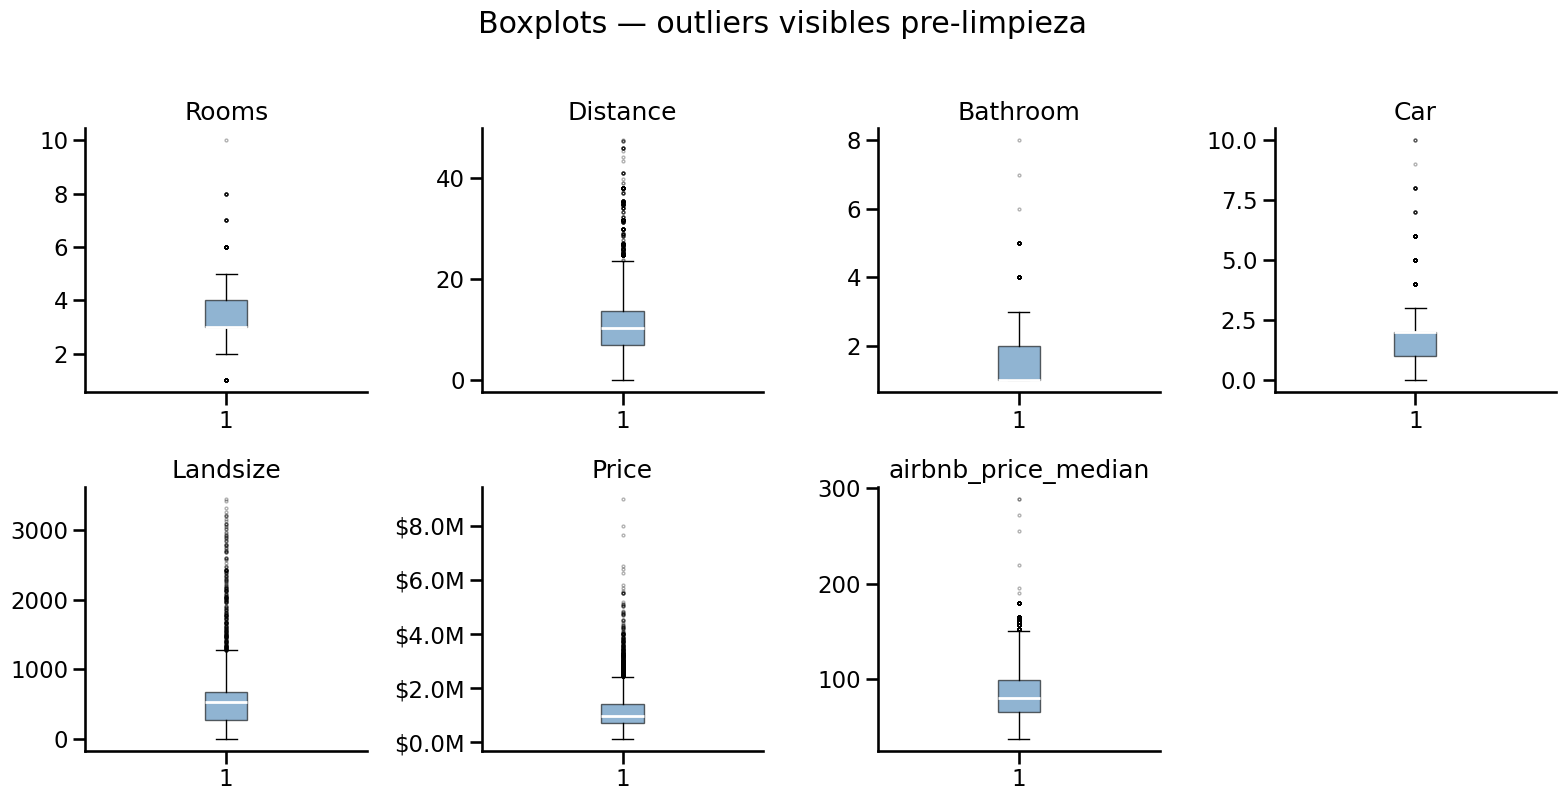

In [63]:
# Boxplots de variables numéricas continuas (excluye coordenadas y variables temporales)
cols_boxplot = ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'Price',
                'airbnb_price_median']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))  # 7 vars + 1 celda vacía
axes = axes.flatten()

for i, col in enumerate(cols_boxplot):
    axes[i].boxplot(melb_seleccionado[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='white', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3, color='steelblue'))
    axes[i].set_title(col)
    axes[i].spines[['top', 'right']].set_visible(False)
    if col == 'Price':
        axes[i].yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

for j in range(len(cols_boxplot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — outliers visibles pre-limpieza', y=1.01)
plt.tight_layout()
plt.show()

Se observa que:

- Price y Landsize: tienen colas derechas largas con outliers extremos que pueden
  distorsionar el  modelo predictivo.
- Distance: presenta outliers hacia valores altos (superiores a 30 km), correspondientes
  a propiedades muy alejadas del CBD que a lo mejor son poco representativas del mercado metropolitano.
- Car: tiene outliers puntuales con valores superiores a 5, casos atípicos que no
  representan el mercado residencial general.
- Rooms y Bathroom: presentan outliers puntuales en valores altos (8+ ambientes,
  6+ baños) que corresponden a propiedades de lujo o errores de carga.
- airbnb_price_median: presenta outliers en la cola superior, reflejo de zipcodes premium con precios de alquiler muy por encima del mercado general.

A partir de este análisis se definen los umbrales de limpieza del ítem 4.

### 2.4. Eliminar valores extremos

Inicialmente se analiza airbnb_price_median antes de decidir no tratar sus outliers.

Estadísticas airbnb_price_median:
count    11407.0
mean        84.8
std         29.4
min         37.5
25%         65.0
50%         80.0
75%         99.0
max        289.0
Name: airbnb_price_median, dtype: float64


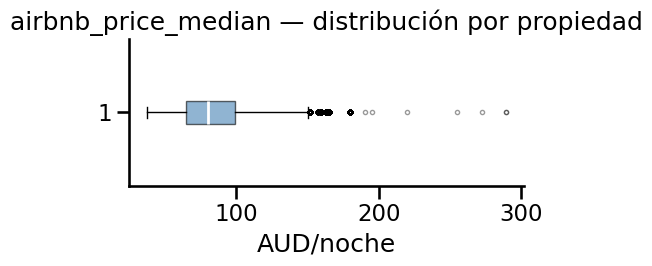


Valor máximo: $289/noche — plausible para zipcode premium de Melbourne.
No se aplica filtro de outliers: son estadísticas agregadas reales, no errores de carga.


In [64]:
# Análisis de airbnb_price_median
print("Estadísticas airbnb_price_median:")
print(melb_seleccionado['airbnb_price_median'].describe().round(1))

# Boxplot
fig, ax = plt.subplots(figsize=(5, 3))
ax.boxplot(melb_seleccionado['airbnb_price_median'].dropna(),
           vert=False, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='white', linewidth=2),
           flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax.set_title('airbnb_price_median — distribución por propiedad')
ax.set_xlabel('AUD/noche')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

max_val = melb_seleccionado['airbnb_price_median'].max()
print(f"\nValor máximo: ${max_val:.0f}/noche — plausible para zipcode premium de Melbourne.")
print("No se aplica filtro de outliers: son estadísticas agregadas reales, no errores de carga.")

El boxplot muestra una distribución sesgada a la derecha. Los outliers visibles a partir de 150 AUD corresponden a zipcodes de alta demanda turística y residencial.
Estos valores son esperables en el mercado, no representan errores de carga.
Por este motivo no se aplica filtro de outliers sobre esta variable, eliminarlos
implicaría perder información real sobre el atractivo del entorno, que es precisamente
lo que airbnb_price_median busca capturar como feature predictora.

Para variables continuas con distribución sesgada (Price, Landsize, Distance) se
aplica un corte en el percentil 99, eliminando el 1% más extremo sin asumir un umbral
fijo arbitrario. Para variables discretas (Rooms, Bathroom, Car) se usan umbrales
fijos basados en criterio de dominio: una propiedad con más de 6 ambientes, 4 baños o
6 cocheras es un caso atípico que no representa el mercado residencial general de Melbourne.

Las variables de AirBnB no se filtran por outliers en este punto ya que son estadísticas
agregadas por zipcode, sus valores extremos reflejan zipcodes premium reales y no errores
de carga.

In [65]:
melb_antes_outliers = len(melb_seleccionado)

limites = {
    'Price':    melb_seleccionado['Price'].quantile(0.99),
    'Landsize': melb_seleccionado['Landsize'].quantile(0.99),
    'Distance': melb_seleccionado['Distance'].quantile(0.99),
    'Rooms':    6,
    'Bathroom': 4,
    'Car':      6,
}

print("Umbrales definidos:")
for col, umbral in limites.items():
    n = (melb_seleccionado[col] > umbral).sum()
    print(f"  {col}: umbral={umbral:.1f} → {n} filas sobre el umbral ({n/melb_antes_outliers:.1%})")

Umbrales definidos:
  Price: umbral=3450000.0 → 114 filas sobre el umbral (1.0%)
  Landsize: umbral=2022.3 → 115 filas sobre el umbral (1.0%)
  Distance: umbral=34.1 → 113 filas sobre el umbral (1.0%)
  Rooms: umbral=6.0 → 18 filas sobre el umbral (0.2%)
  Bathroom: umbral=4.0 → 28 filas sobre el umbral (0.2%)
  Car: umbral=6.0 → 19 filas sobre el umbral (0.2%)


In [66]:
# Guardamos copia pre-limpieza para comparar visualmente en el ítem 5
melb_pre_outliers = melb_seleccionado.copy()

# Percentil 99 para variables con distribución sesgada
for col in ['Price', 'Landsize', 'Distance']:
    q99 = melb_seleccionado[col].quantile(0.99)
    melb_seleccionado = melb_seleccionado[melb_seleccionado[col] <= q99]

# Umbrales fijos para variables discretas
melb_seleccionado = melb_seleccionado[melb_seleccionado['Rooms'] <= 6]
melb_seleccionado = melb_seleccionado[melb_seleccionado['Bathroom'] <= 4]
melb_seleccionado = melb_seleccionado[melb_seleccionado['Car'] <= 6]

filas_eliminadas = melb_antes_outliers - len(melb_seleccionado)
print(f"Filas eliminadas: {filas_eliminadas} ({filas_eliminadas/melb_antes_outliers:.1%})")
print(f"Shape final: {melb_seleccionado.shape}")

Filas eliminadas: 390 (3.4%)
Shape final: (11033, 14)


Se eliminó el 3.4% de las filas (390 registros) correspondientes a valores extremos.
Los umbrales por percentil 99 afectaron principalmente Price, Landsize y Distance
con aproximadamente 114–115 filas cada uno. Los umbrales fijos para Rooms, Bathroom
y Car eliminaron un número menor de casos (18–28 filas), lo que indica que la limpieza
del Ej 1 ya había acotado bastante esas variables.

En todos los casos la eliminación afecta únicamente a los extremos superiores, sin
modificar la distribución central del dataset.

### 2.5. Visualizar los outliers eliminados

Se grafican boxplots comparativos antes y después de la limpieza para las tres variables
continuas donde se aplicó el corte por percentil 99: Price, Landsize y Distance.

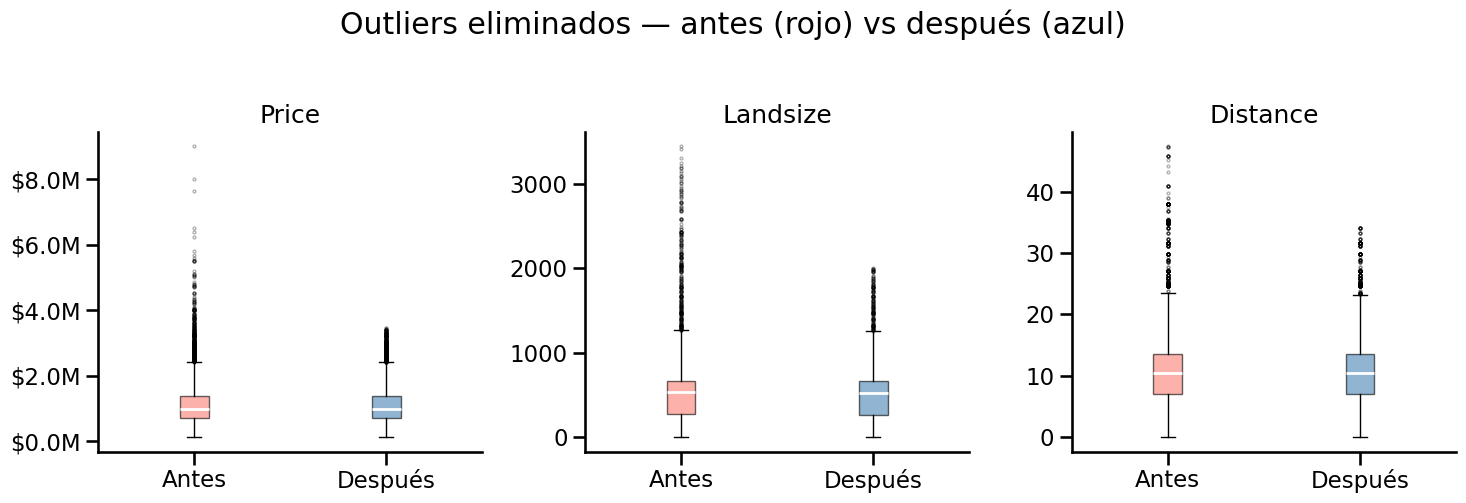

In [67]:
cols_outliers = ['Price', 'Landsize', 'Distance']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, cols_outliers):
    bp = ax.boxplot(
        [melb_pre_outliers[col].dropna(), melb_seleccionado[col].dropna()],
        tick_labels=['Antes', 'Después'],
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2),
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    bp['boxes'][0].set_facecolor('salmon')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('steelblue')
    bp['boxes'][1].set_alpha(0.6)

    ax.set_title(col)
    ax.spines[['top', 'right']].set_visible(False)

    if col == 'Price':
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

plt.suptitle('Outliers eliminados — antes (rojo) vs después (azul)', y=1.02)
plt.tight_layout()
plt.show()

En las visualizaciones se observa que en Price se eliminaron propiedades con valores superiores a 3.45M, acortando
notablemente la cola superior. En Landsize se cortaron terrenos por encima de
los 2000 m², reduciendo los valores extremos visibles. En Distance el efecto es
menor visualmente porque los outliers estaban concentrados en pocos casos por encima
de los 34 km.

En los tres casos la caja intercuartílica (IQR) no se modifica, lo que confirma que
la limpieza solo afectó los extremos sin alterar la distribución central de los datos.

### 2.6. Agregar información adicional de AirBnB

In [68]:

# Se valida que las columnas AirBnB están presentes y el join es correcto.

cols_airbnb = ['airbnb_price_median', 'airbnb_record_count',
               'airbnb_weekly_price_median', 'airbnb_monthly_price_median']
print("Columnas AirBnB disponibles:", [c for c in cols_airbnb if c in merged_sales_df.columns])

cobertura_join = merged_sales_df['airbnb_price_median'].notna().mean()
print(f"Cobertura del join (airbnb_price_median no nulo): {cobertura_join:.1%}")
print(f"Shape post-join: {merged_sales_df.shape}")



Columnas AirBnB disponibles: ['airbnb_price_median', 'airbnb_record_count', 'airbnb_weekly_price_median', 'airbnb_monthly_price_median']
Cobertura del join (airbnb_price_median no nulo): 99.9%
Shape post-join: (11423, 24)


Las 4 columnas de AirBnB están presentes en el dataset. La cobertura del 99.9% confirma
que el join por zipcode/Postcode fue exitoso y no generó pérdida de registros.
El shape (11423, 24) es consistente con el dataset original del Ej 1.
Se retiene únicamente airbnb_price_median por ser la variable con mayor correlación.

Se usa la mediana y no la media porque la distribución de precios AirBnB está sesgada
a la derecha, la media sería arrastrada por propiedades premium y no representaría el
valor típico del zipcode.



### 2.7. Filtrar zipcodes con mínimo de registros

Para asegurar que la mediana sea representativa, se consideran solo los zipcodes con
al menos 10 listings en AirBnB.

In [69]:
MIN_REGISTROS = 10
airbnb_filtrado = airbnb_price_by_zipcode[
    airbnb_price_by_zipcode['airbnb_record_count'] >= MIN_REGISTROS
]

excluidos = len(airbnb_price_by_zipcode) - len(airbnb_filtrado)
print(f"Zipcodes antes del filtro:  {len(airbnb_price_by_zipcode)}")
print(f"Zipcodes con >= {MIN_REGISTROS} listings: {len(airbnb_filtrado)}")
print(f"Zipcodes excluidos: {excluidos} ({excluidos/len(airbnb_price_by_zipcode):.1%})")

# Propiedades cubiertas con el filtro aplicado
cobertura = melb_seleccionado['Postcode'].isin(airbnb_filtrado['zipcode']).mean()
print(f"\nCobertura sobre melb_seleccionado: {cobertura:.1%} de propiedades en zipcodes con >= {MIN_REGISTROS} listings")

Zipcodes antes del filtro:  248
Zipcodes con >= 10 listings: 183
Zipcodes excluidos: 65 (26.2%)

Cobertura sobre melb_seleccionado: 95.7% de propiedades en zipcodes con >= 10 listings


Si bien se excluyen 65 zipcodes (26,2% del total), estos corresponden a zonas de baja
actividad turística donde la información de AirBnB no aportaría valor predictivo confiable. Se considera que con menos de 10 listings la mediana no es representativa del mercado de alquiler de esa
zona. Los 183 zipcodes restantes cubren el 95,7% de las propiedades de melb_seleccionado,
lo que valida que el filtro aplicado no genera una pérdida significativa de cobertura.

In [70]:
# Validación post-filtro
assert len(melb_seleccionado) == 11033, \
    f"Error: cantidad de filas inesperada: {len(melb_seleccionado)}"

for col in ['Rooms', 'Price', 'Suburb', 'Type']:
    assert melb_seleccionado[col].isna().sum() == 0, \
        f"'{col}' tiene nulos inesperados"

cobertura_pct = melb_seleccionado['airbnb_price_median'].notna().mean()
assert cobertura_pct > 0.5, \
    "Menos del 50% de propiedades tiene info AirBnB — revisar join"

assert melb_seleccionado['airbnb_price_median'].dropna().between(0, 2000).all(), \
    "Precio AirBnB fuera de rango esperado"
assert melb_seleccionado['Price'].between(0, 5_000_000).all(), \
    "Price fuera de rango esperado post-limpieza"

print(f"✓ Filas conservadas: {len(melb_seleccionado)}")
print(f"✓ Cobertura AirBnB: {cobertura_pct:.1%}")
print(f"✓ Columnas totales: {melb_seleccionado.shape[1]}")
print("✓ Todas las validaciones pasaron correctamente")

✓ Filas conservadas: 11033
✓ Cobertura AirBnB: 99.9%
✓ Columnas totales: 14
✓ Todas las validaciones pasaron correctamente


In [71]:
#Tabla resumen
tabla_resumen = melb_seleccionado.groupby('Postcode').agg(
    cantidad_propiedades=('Price', 'count'),
    precio_venta_mediano=('Price', 'median'),
    airbnb_price_median=('airbnb_price_median', 'first'),
).reset_index()

tabla_resumen = tabla_resumen[tabla_resumen['airbnb_price_median'].notna()]
tabla_resumen = tabla_resumen.sort_values('precio_venta_mediano', ascending=False).head(15)

tabla_resumen['precio_venta_mediano'] = tabla_resumen['precio_venta_mediano'].apply(lambda x: f'${x:,.0f}')
tabla_resumen['airbnb_price_median'] = tabla_resumen['airbnb_price_median'].apply(lambda x: f'${x:.0f}')

tabla_resumen.columns = ['Zipcode', 'Cant. propiedades', 'Precio venta mediano', 'AirBnB precio/noche']
tabla_resumen = tabla_resumen.reset_index(drop=True)
display(tabla_resumen)

,Zipcode,Cant. propiedades,Precio venta mediano,AirBnB precio/noche
0,3144,36,"$1,985,000",$140
1,3126,42,"$1,890,000",$140
2,3186,137,"$1,865,000",$160
3,3103,87,"$1,850,000",$71
4,3206,85,"$1,850,000",$165
5,3052,12,"$1,828,000",$73
6,3101,124,"$1,800,000",$96
7,3124,111,"$1,775,000",$96
8,3102,44,"$1,760,000",$78
9,3146,159,"$1,751,000",$100


### 2.8 Análisis del zipcode



In [72]:
print(f"Zipcodes únicos en melb_seleccionado: {melb_seleccionado['Postcode'].nunique()}")
print(f"Propiedades con info AirBnB: {melb_seleccionado['airbnb_price_median'].notna().sum()}")
print(f"Cobertura: {melb_seleccionado['airbnb_price_median'].notna().mean():.1%}")
print(f"\nPrecio mediano AirBnB por noche:")
print(f"  Mínimo:  ${melb_seleccionado['airbnb_price_median'].min():.1f}")
print(f"  Máximo:  ${melb_seleccionado['airbnb_price_median'].max():.1f}")
print(f"  Mediana: ${melb_seleccionado['airbnb_price_median'].median():.1f}")
print(f"  Media:   ${melb_seleccionado['airbnb_price_median'].mean():.1f}")

Zipcodes únicos en melb_seleccionado: 176
Propiedades con info AirBnB: 11026
Cobertura: 99.9%

Precio mediano AirBnB por noche:
  Mínimo:  $37.5
  Máximo:  $289.0
  Mediana: $79.5
  Media:   $84.3


El dataset cuenta con 176 zipcodes únicos, que tienen al menos 10 listings
en AirBnB según airbnb_filtrado. La cobertura es del 99,9% ,  la totalidad de las
11.026 propiedades tiene información AirBnB disponible en su zipcode.

El precio mediano AirBnB por noche varía entre 37,5 y 289 AUD, con una mediana global
de 79,5 AUD y media de 84,3 AUD. La diferencia entre media y mediana confirma que la
distribución está sesgada a la derecha: hay zipcodes premium que elevan la media, lo que
refuerza la decisión de usar la mediana como estadístico de agregación.

Los zipcodes con mayor precio AirBnB se concentran en zonas de alta demanda turística
y residencial de Melbourne. La hipótesis es que estos zipcodes también presentan precios
de compra más altos, lo que se analizará visualmente en el gráfico del punto 2.9.

### 2.9 Gráfico zipcode vs airbnb_price_median

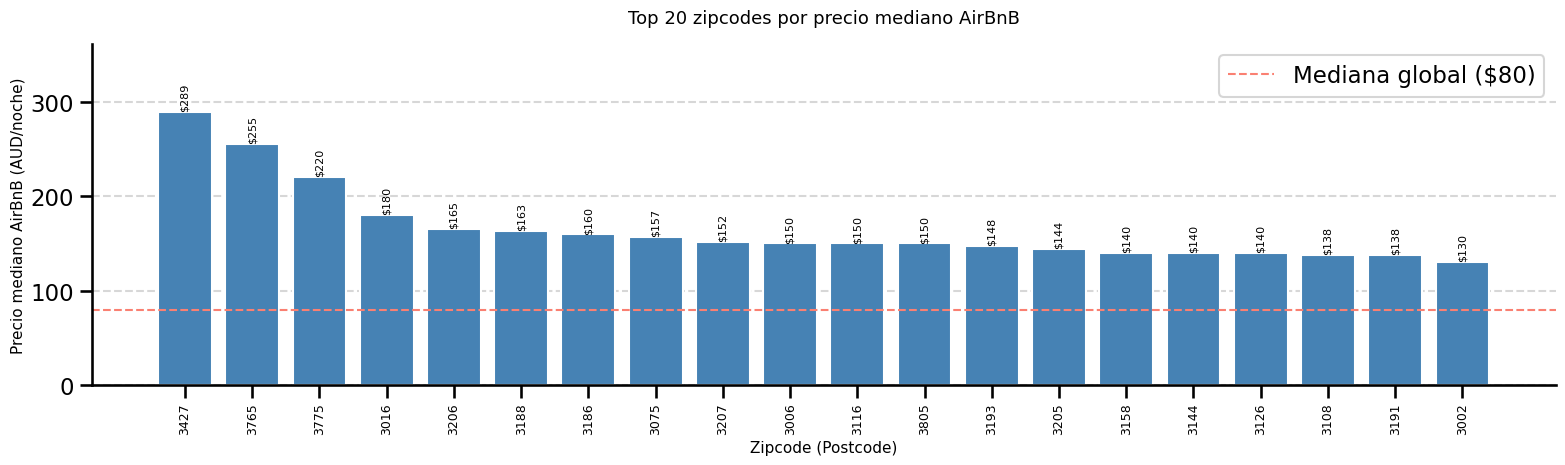

In [73]:
airbnb_por_zipcode = (
    melb_seleccionado[melb_seleccionado['airbnb_price_median'].notna()]
    .groupby('Postcode')['airbnb_price_median']
    .first()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(16, 5))

bars = ax.bar(airbnb_por_zipcode['Postcode'].astype(str),
              airbnb_por_zipcode['airbnb_price_median'],
              color='steelblue', edgecolor='white')

for bar, precio in zip(bars, airbnb_por_zipcode['airbnb_price_median']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'${precio:.0f}', ha='center', va='bottom', fontsize=8, rotation=90)

mediana_global = melb_seleccionado['airbnb_price_median'].median()
ax.axhline(mediana_global, color='salmon', linestyle='--', linewidth=1.5,
           label=f'Mediana global (${mediana_global:.0f})')

ax.set_title('Top 20 zipcodes por precio mediano AirBnB', fontsize=13, pad=15)
ax.set_ylabel('Precio mediano AirBnB (AUD/noche)', fontsize=11)
ax.set_xlabel('Zipcode (Postcode)', fontsize=11)
ax.set_xticks(range(len(airbnb_por_zipcode)))
ax.set_xticklabels(airbnb_por_zipcode['Postcode'].astype(str), rotation=90, fontsize=9)
ax.set_ylim(0, airbnb_por_zipcode['airbnb_price_median'].max() * 1.25)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [74]:
# Tabla resumen
zipcodes_en_dataset = melb_seleccionado['Postcode'].unique()

tabla = (
    airbnb_filtrado[airbnb_filtrado['zipcode'].isin(zipcodes_en_dataset)]
    .sort_values('airbnb_price_median', ascending=False)
    .head(10)
    .copy()
)

tabla = tabla[['zipcode', 'airbnb_price_median', 'airbnb_record_count']]
tabla.columns = ['Zipcode', 'Precio mediano (AUD/noche)', 'Cantidad listings']

tabla['Precio mediano (AUD/noche)'] = tabla['Precio mediano (AUD/noche)'].apply(lambda x: f'${x:.0f}')
tabla = tabla.reset_index(drop=True)
display(tabla)

,Zipcode,Precio mediano (AUD/noche),Cantidad listings
0,3775,$220,45
1,3016,$180,74
2,3206,$165,122
3,3188,$163,71
4,3186,$160,124
5,3075,$157,10
6,3207,$152,257
7,3006,$150,1268
8,3116,$150,11
9,3805,$150,34


El gráfico muestra una caída pronunciada desde el zipcode 3427 (289 AUD/noche) hacia
un segundo grupo (3765, 3775) en torno a 220–255 AUD/noche, y luego una curva más gradual que
se aplana en el rango 130–165 AUD/noche a partir del zipcode 3188. Todos los zipcodes
del top 20 superan ampliamente la mediana global de 80 AUD, confirmando que representan
zonas con mercado de alquiler significativamente más activo que el promedio.

### 2.10. Otras 2 variables para combinar los datasets

Se investigan otras 2 variables candidatas para combinar los datasets además de zipcode: suburb y neighborhood. Para cada una se analiza la cobertura potencial del match contra las variables de ubicación del dataset de Melbourne.

Suburb: porque es la variable de ubicación disponible en Airbnb además de zipcode. El dataset de Melbourne tiene Suburb como columna, entonces hay candidato directo para el join. Además, como nombra un área geográfica real, lo hace más simple para validar.

Neighborhood: Airbnb la define como el barrio percibido por el anunciante, que puede diferrir el suburb adminsitrativo, lo que captura la identidad del mercado de una zona, lo que mueve los precios.

In [75]:
# Normalización para comparar
def normalizar(s):
    return str(s).strip().lower()

suburbs_melb = set(merged_sales_df['Suburb'].dropna().map(normalizar).unique())
suburbs_airbnb = set(airbnb_df['suburb'].dropna().map(normalizar).unique())
neighborhoods_airbnb = set(airbnb_df['neighborhood'].dropna().map(normalizar).unique())

# Cobertura por match exacto
match_suburb = suburbs_melb & suburbs_airbnb
match_neighborhood = suburbs_melb & neighborhoods_airbnb

print(f"Suburbs en Melbourne:       {len(suburbs_melb)}")
print(f"Suburbs en AirBnB:          {len(suburbs_airbnb)}")
print(f"Match exacto suburb:        {len(match_suburb)} ({len(match_suburb)/len(suburbs_melb):.1%})")
print(f"Neighborhoods en AirBnB:    {len(neighborhoods_airbnb)}")
print(f"Match exacto neighborhood:  {len(match_neighborhood)} ({len(match_neighborhood)/len(suburbs_melb):.1%})")

Suburbs en Melbourne:       309
Suburbs en AirBnB:          523
Match exacto suburb:        293 (94.8%)
Neighborhoods en AirBnB:    59
Match exacto neighborhood:  50 (16.2%)


In [76]:
# Cobertura sobre melb_seleccionado con cada variable de join
zipcodes_en_dataset = melb_seleccionado['Postcode'].unique()

cobertura_zipcode = melb_seleccionado['Postcode'].isin(airbnb_filtrado['zipcode']).mean()
cobertura_suburb  = melb_seleccionado['Suburb'].map(normalizar).isin(match_suburb).mean()
cobertura_neighb  = melb_seleccionado['Suburb'].map(normalizar).isin(match_neighborhood).mean()

print(f"Cobertura por zipcode:      {cobertura_zipcode:.1%}")
print(f"Cobertura por suburb:       {cobertura_suburb:.1%}")
print(f"Cobertura por neighborhood: {cobertura_neighb:.1%}")

Cobertura por zipcode:      95.7%
Cobertura por suburb:       99.0%
Cobertura por neighborhood: 34.2%


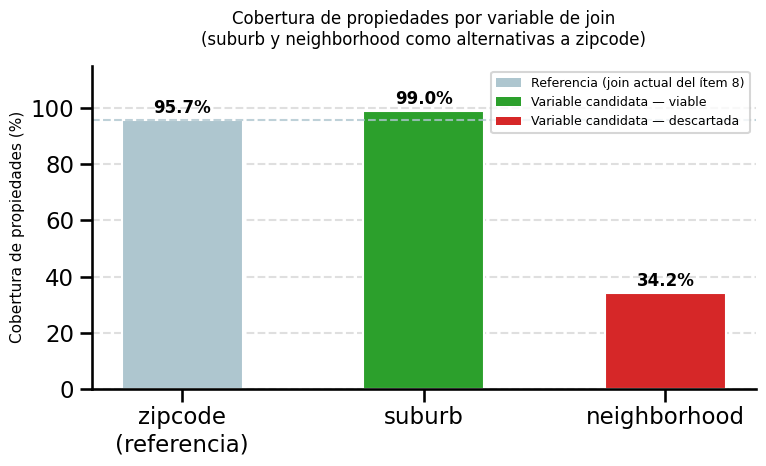

In [77]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

variables = ['zipcode\n(referencia)', 'suburb', 'neighborhood']
coberturas = [95.7, 99.0, 34.2]
colores = ['#aec6cf', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(variables, coberturas, color=colores, edgecolor='white', width=0.5)

for bar, val in zip(bars, coberturas):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.axhline(95.7, color='#aec6cf', linestyle='--', linewidth=1.5, alpha=0.8)

ax.set_ylim(0, 115)
ax.set_ylabel('Cobertura de propiedades (%)', fontsize=11)
ax.set_title('Cobertura de propiedades por variable de join\n(suburb y neighborhood como alternativas a zipcode)',
             fontsize=12, pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

leyenda = [
    Patch(facecolor='#aec6cf', label='Referencia (join actual del ítem 8)'),
    Patch(facecolor='#2ca02c', label='Variable candidata — viable'),
    Patch(facecolor='#d62728', label='Variable candidata — descartada'),
]
ax.legend(handles=leyenda, fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

El gráfico compara la cobertura de propiedades de Melbourne que quedarían
cubiertas al usar cada variable de join con AirBnB.

- zipcode (referencia): 95,7% de cobertura con el join ya implementado. Es la variable preferida por ser un código estandarizado, sin ambigüedad de escritura ni dependencia de nombres informales.

- suburb: 99% de cobertura, superando a zipcode. El match de nombres es alto, pero AirBnB incluye suburbs propios no presentes en Melbourne, lo que indica que algunos anunciantes usan nombres informales o subdivisiones no oficiales. Es una alternativa viable y podría usarse como complemento para cubrir los zipcodes sin match, siempre que se valide manualmente la correspondencia de nombres con un experto.

- neighborhood: solo 34,2% de cobertura. Tiene muy pocos valores únicos. lo que significa que agrupa zonas geográficamente muy distintas bajo una misma etiqueta. La granularidad es insuficiente para capturar diferencias de precio entre barrios. Queda descartada.

**Conclusión** zipcode es la variable más robusta para el join. Suburb sería una buen alternativa con normalización de nombres, y una estrategia combinada daría la mejor cobertura posible.

**Si tuviéramos que entrevistar a un experto inmobiliario para validar
el mapeo de barrios entre datasets, le haríamos estas preguntas:**

1. ¿Hay barrios que hayan cambiado de nombre o que se hayan dividido/fusionado administrativamente en los últimos años, de forma que el mismo nombre refiera  a zonas distintas según la fuente?

2. ¿Existen zonas donde la demanda de alquiler o AirbnB no refleje el atractivo residencial del barrio? Por ejemplo, zonas industriales o comerciales con alta actividad Airbnb pero bajo valor de compraventa, o zonas residenciales premium sin presencia Airbnb.

3. ¿Qué barrios considerarías equivalentes entre el mercado de alquiler turístico y el de compraventa, aunque tengan nombres distintos en cada dataset? Por ejemplo, zonas que los compradores conocen por un nombre ero que los anunciantes de Airbnb llaman de otra manera.

### 2.11 Uso de coordenadas geoespaciales

Las coordenadas geoespaciales ya están disponibles en ambos datasets:
Lattitude y Longtitude en Melbourne, latitude y longitude en AirBnB.
Esto permitiría reemplazar el join por zipcode con un join por proximidad:
para cada propiedad de Melbourne, tomar los n listings AirBnB más cercanos y calcular la mediana de precio en ese radio.

Esto sería más preciso que el zipcode por dos razones:
- Captura el entorno inmediato real de la propiedad, sin depender de límites administrativos que pueden ser internamente heterogéneos.
- Permite ajustar el radio según la densidad urbana: un radio chico en zonas densas (CBD) y uno más amplio en zonas periféricas con pocos listings.

La implementación sería directa con BallTree de scikit-learn usando
métrica haversine.

In [78]:
# Verificar disponibilidad de coordenadas en ambos datasets
print("Melbourne:")
print(melb_seleccionado[['Lattitude', 'Longtitude']].notna().sum())
print("\nAirBnB:")
print(airbnb_df[['latitude', 'longitude']].notna().sum())

Melbourne:
Lattitude     11033
Longtitude    11033
dtype: int64

AirBnB:
latitude     22895
longitude    22895
dtype: int64


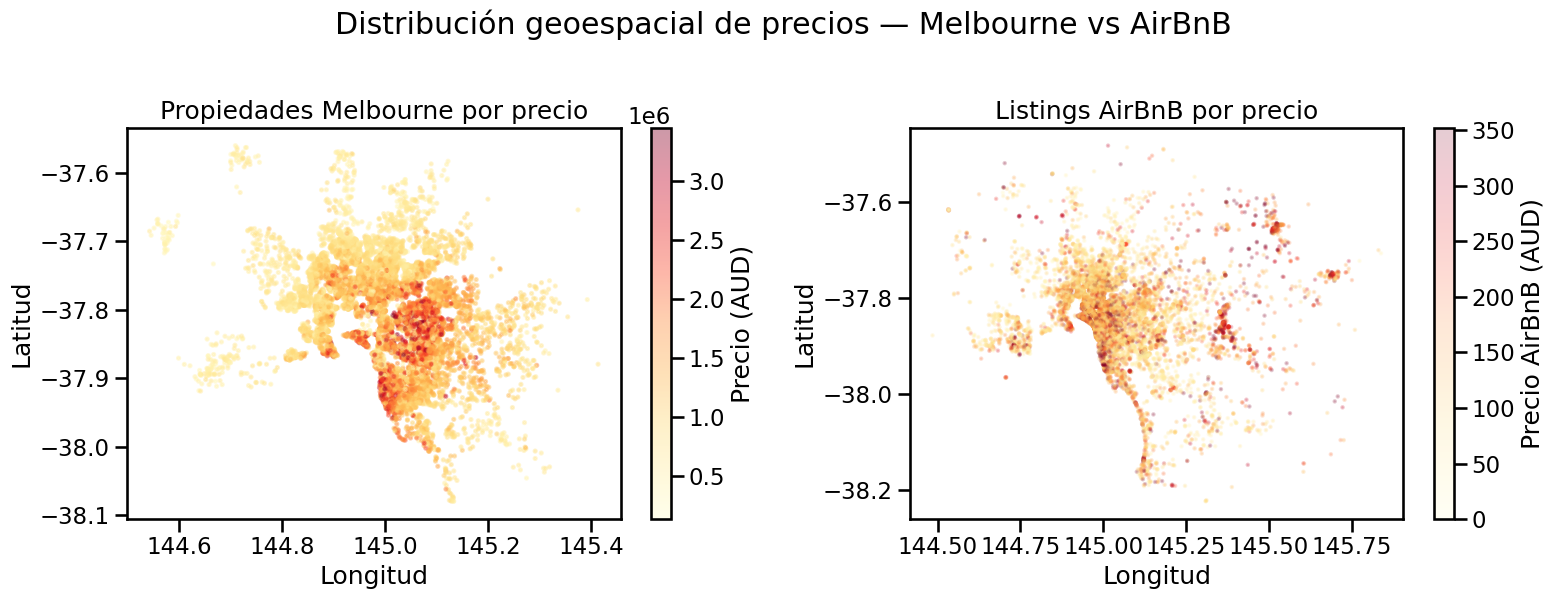

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Propiedades Melbourne coloreadas por precio
sc = axes[0].scatter(
    melb_seleccionado['Longtitude'], melb_seleccionado['Lattitude'],
    c=melb_seleccionado['Price'], cmap='YlOrRd', alpha=0.4, s=5
)
plt.colorbar(sc, ax=axes[0], label='Precio (AUD)')
axes[0].set_title('Propiedades Melbourne por precio')
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')

# AirBnB listings coloreados por precio
airbnb_plot = airbnb_df[airbnb_df['latitude'].notna() & airbnb_df['longitude'].notna()].copy()
airbnb_plot['price_num'] = pd.to_numeric(airbnb_plot['price'], errors='coerce')

sc2 = axes[1].scatter(
    airbnb_plot['longitude'], airbnb_plot['latitude'],
    c=airbnb_plot['price_num'], cmap='YlOrRd', alpha=0.2, s=3,
    vmax=airbnb_plot['price_num'].quantile(0.95)
)
plt.colorbar(sc2, ax=axes[1], label='Precio AirBnB (AUD)')
axes[1].set_title('Listings AirBnB por precio')
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')

plt.suptitle('Distribución geoespacial de precios — Melbourne vs AirBnB', y=1.01)
plt.tight_layout()
plt.show()

Los mapas confirman que ambos datasets cubren la misma área geográfica, área metropolitana de Melbourne, lo que valida que un join por proximidad
geoespacial sería factible.

Se observa que:

- Melbourne: los precios más altos (tonos oscuros) se concentran en el centro y en algunas zonas al sureste, mientras que la periferia presenta precios más bajos. La densidad de propiedades es mayor en el anillo interior de la ciudad.

- AirBnB: los listings se concentran fuertemente en el centro (CBD) y se dispersan hacia la periferia con menor densidad. Los precios más altos también aparecen en el centro y en zonas costeras al sureste.

Ambos mapas muestran una correlación espacial, las zonas con precios de venta más altos tienden a coincidir con las zonas de mayor precio Airbnb, lo que refuerza la hipótesis de que airbnb_price_median es un indicador relevante del atractivo del entorno.

Un join por proximidad (radio fijo o n vecinos más cercanos con distancia
haversine) capturaría este patrón de forma más precisa que el zipcode,
ya que operaría directamente sobre la posición geográfica de cada propiedad
sin depender de límites administrativos.

**¿Qué variables adicionales mejorarían la predicción del precio?**

Variables de la propiedad:  

*   Estado de refacción / renovación: una propiedad renovada vale más que una en mal estado.
*  Vista al agua o parque: diferencia propiedades de precio similar estructuralmente.
*   Propiedad con piscina o jardín propio: amenities que impactan directamente en el valor.

Variables del entorno:
*   Cercanía del transporte público (tren/ tranvía): en ciudades grandes esto impacta en el precio.
*  Calidad del colegio más cercano: clave para familias, genera sobreprecio en los zipcodes con mejores colegios.
*   Nivel de ruido del entorno: distingue zonas residenciales tranquilas de zona de alto tráfico o actividad comercial.

Variables macroeconómicas:
*   Tasas de interés al momento de la venta: el contexto crediticio afecta directamente la demanda y los precios de mercado.
*   Historial de ventas previas de la propiedad: indica la tendencia de revalorización.

## Ejercicio 3:

Crear y guardar un nuevo conjunto de datos con todas las transformaciones realizadas anteriormente.

## Ejercicios opcionales:

El notebook `02.2 ETLs-DAGs.ipynb` tiene un esqueleto de referencia para guiarse.

1. Armar un script en python (archivo .py) [ETL](https://towardsdatascience.com/what-to-log-from-python-etl-pipelines-9e0cfe29950e) que corra los pasos de extraccion, transformacion y carga, armando una funcion para cada etapa del proceso y luego un main que corra todos los pasos requeridos.



1. Respuesta : Armar un script en python (archivo .py) ETL que corra los pasos de extraccion, transformacion y carga, armando una funcion para cada etapa del proceso y luego un main que corra todos los pasos requeridos.

Por un problema de eficiencia los ETL no deberían tener grandes bloques de memoria cargados. Los procesos se basan en consultas a la base de datos transformación y almacenamiento, no tanto en cargar toda la información en memoria y procesarla.
Por esto se crea una función que va a generar una base de datos para emular el proceso. Normalmente se brinda la base de datos donde la información está almacenada. En esos casos esa función no se ejecuta y se pasa derecho al paso de extracción de la información.

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

def crear_bd_con_sqlalchemy(csv_path, db_path, table_name):
    """
    Toma un archivo CSV y lo guarda en una base de datos relacional
    utilizando un motor de conexión gestionado por SQLAlchemy.
    """
    print("1. Inicializando el motor (Engine) de SQLAlchemy...")
    # Creamos el motor de conexión. Para SQLite local se usan 3 barras diagonales: sqlite:///
    # El parámetro echo=True opcional te permite ver en consola las sentencias SQL reales que se ejecutan por detrás
    engine = create_engine(f'sqlite:///{db_path}', echo=False)

    try:
        print(f"2. Leyendo datos desde el CSV: {csv_path}")
        df = pd.read_csv(csv_path)

        print("   -> Agregando la columna 'Paridad' con valor 'NO EVALUADA'...")
        df['Paridad'] = "NO EVALUADA"

        print(f"3. Volcando {len(df)} filas en la tabla '{table_name}' usando SQLAlchemy...")
        # Pandas detecta de forma nativa el motor de SQLAlchemy al pasarlo en el parámetro 'con'
        df.to_sql(
            name=table_name,
            con=engine,
            if_exists='replace',
            index=False
        )

        print("¡Proceso de carga completado con éxito mediante SQLAlchemy!")

    except Exception as e:
        print(f"Ocurrió un error en el proceso: {e}")

    finally:
        # En versiones modernas de SQLAlchemy, el motor maneja el pool de conexiones de forma autónoma.
        # Es una buena práctica liberar los recursos del motor al finalizar la aplicación pesada.
        engine.dispose()
        print("Recursos del motor de SQLAlchemy liberados.")

# --- Ejecución del Script ---
if __name__ == "__main__":
    archivo_csv = 'melb_data_extended.csv'  # Archivo resultante del ETL
    archivo_db = 'melbourne_sqlalchemy.db'         # Nombre de la nueva BD SQLite
    nombre_tabla = 'propiedades_rentas'             # Nombre de la tabla destino

    crear_bd_con_sqlalchemy(archivo_csv, archivo_db, nombre_tabla)

1. Inicializando el motor (Engine) de SQLAlchemy...
2. Leyendo datos desde el CSV: melb_data_extended.csv
   -> Agregando la columna 'Paridad' con valor 'NO EVALUADA'...
3. Volcando 11423 filas en la tabla 'propiedades_rentas' usando SQLAlchemy...
¡Proceso de carga completado con éxito mediante SQLAlchemy!
Recursos del motor de SQLAlchemy liberados.


Verificación de la Generación de la Base de datos.

In [ ]:
from sqlalchemy import create_engine
import pandas as pd

# Conectamos al nuevo archivo generado
engine = create_engine('sqlite:///melbourne_sqlalchemy.db')

# Definimos la consulta de prueba
"""
query =
SELECT Postcode, Price, Rooms, airbnb_price_median, Paridad
FROM propiedades_rentas
WHERE Rooms > 3
LIMIT 5;
"""

query = """
SELECT *
FROM propiedades_rentas
WHERE Rooms > 3
LIMIT 5;
"""

# Ejecutamos la consulta pasándole el motor de SQLAlchemy
df_verificacion = pd.read_sql_query(query, con=engine)

print("\n--- Verificación: Propiedades con más de 3 habitaciones ---")
print(df_verificacion)

# Liberamos recursos
engine.dispose()


--- Verificación: Propiedades con más de 3 habitaciones ---
         Suburb           Address  Rooms Type      Price Method     SellerG  \
0    Abbotsford       55a Park St      4    h  1600000.0     VB      Nelson   
1    Abbotsford   3/72 Charles St      4    h  1330000.0     PI         Kay   
2  Airport West     36 Roberts Rd      4    h   785000.0      S   Considine   
3  Airport West  11 Harrington Rd      6    h   725000.0     SP       Barry   
4  Airport West      241 Parer Rd      5    h   755000.0     PI  Propertyau   

   Distance  Postcode  Bathroom  ...             Regionname  Propertycount  \
0       2.5      3067         1  ...  Northern Metropolitan           4019   
1       2.5      3067         2  ...  Northern Metropolitan           4019   
2      13.5      3042         1  ...   Western Metropolitan           3464   
3      13.5      3042         3  ...   Western Metropolitan           3464   
4      13.5      3042         2  ...   Western Metropolitan           3464

Se ejecuta la query para verifficar cuantos campos y con que valor estan cargados.

In [ ]:
# Conectamos al nuevo archivo generado
engine = create_engine('sqlite:///melbourne_sqlalchemy.db')

# Definimos la consulta de prueba

query = """
    SELECT Paridad, COUNT(*) as cantidad_propiedades
    FROM propiedades_rentas
    GROUP BY Paridad
    ORDER BY cantidad_propiedades DESC;
"""

# Ejecutamos la consulta pasándole el motor de SQLAlchemy
df_verificacion = pd.read_sql_query(query, con=engine)

print("\n--- Verificación: Propiedades con más de 3 habitaciones ---")
print(df_verificacion)

# Liberamos recursos
engine.dispose()


--- Verificación: Propiedades con más de 3 habitaciones ---
       Paridad  cantidad_propiedades
0  NO EVALUADA                 11423


Ejecucion del ETL propiamente dicho.
El script toma un chunk de información de la base de datos. Hace un rápido proceso de reemplazar el valor de "No Evaluado" por "PAR" en casso de que el price sea par, "IMPAR" en caso de que o sea y "ZERO" en toda otra situación.
El proceso se completa guardando en la misma base de datos.
Este proceso puede involucrar cualquier otra tarea que requiera un procesado de informacion de porma periódica.


In [ ]:
import pandas as pd
from sqlalchemy import create_engine, text

def determinar_paridad(precio):
    try:
        if pd.isna(precio): return "ZERO"
        val = float(precio)
        if val == 0: return "ZERO"
        elif val % 2 == 0: return "PAR"
        else: return "IMPAR"
    except:
        return "ZERO"

def etl_procesamiento_por_lotes_bucle(db_path, tabla_origen, batch_size=1000):
    print(f"--- Iniciando ETL por Lotes con Bucle UPDATE (Batch: {batch_size}) ---")

    engine = create_engine(f'sqlite:///{db_path}', echo=False)

    try:
        # 1. EXTRACCIÓN: Pedimos explícitamente la columna oculta 'rowid'
        # Solo traemos rowid y Price para ahorrar memoria, no necesitamos traer toda la fila
        query = f"SELECT rowid, Price FROM {tabla_origen}"

        # Leemos en lotes
        lotes = pd.read_sql_query(query, con=engine, chunksize=batch_size)
        numero_lote = 1

        # Abrimos una conexión para ejecutar nuestras actualizaciones
        with engine.begin() as conexion:

            # Preparamos la sentencia SQL de actualización.
            # Los dos puntos (:paridad, :id) indican que son variables dinámicas.
            sentencia_update = text(f"UPDATE {tabla_origen} SET Paridad = :paridad WHERE rowid = :id")

            for chunk in lotes:
                print(f"-> Procesando lote {numero_lote} ({len(chunk)} registros)...")

                # 2. TRANSFORMACIÓN: Aplicamos la lógica a todo el chunk
                chunk['Paridad'] = chunk['Price'].apply(determinar_paridad)

                # 3. CARGA: EL BUCLE QUE REEMPLAZA A to_sql()
                # Iteramos fila por fila dentro de este chunk
                for index, fila in chunk.iterrows():

                    # Ejecutamos el UPDATE para cada fila individual
                    conexion.execute(
                        sentencia_update,
                        {"paridad": fila['Paridad'], "id": fila['rowid']}
                    )

                numero_lote += 1

        print(f"\n¡Proceso completado con éxito! Se actualizaron los valores directamente en la tabla original.")

    except Exception as e:
        print(f"Ocurrió un error en el flujo ETL: {e}")

    finally:
        engine.dispose()
        print("Conexión a la base de datos cerrada y liberada.")

# --- Ejecución ---
if __name__ == "__main__":
    archivo_db = 'melbourne_sqlalchemy.db'
    tabla_a_modificar = 'propiedades_rentas'

    etl_procesamiento_por_lotes_bucle(archivo_db, tabla_a_modificar, batch_size=500)

--- Iniciando ETL por Lotes con Bucle UPDATE (Batch: 500) ---
-> Procesando lote 1 (500 registros)...
-> Procesando lote 2 (500 registros)...
-> Procesando lote 3 (500 registros)...
-> Procesando lote 4 (500 registros)...
-> Procesando lote 5 (500 registros)...
-> Procesando lote 6 (500 registros)...
-> Procesando lote 7 (500 registros)...
-> Procesando lote 8 (500 registros)...
-> Procesando lote 9 (500 registros)...
-> Procesando lote 10 (500 registros)...
-> Procesando lote 11 (500 registros)...
-> Procesando lote 12 (500 registros)...
-> Procesando lote 13 (500 registros)...
-> Procesando lote 14 (500 registros)...
-> Procesando lote 15 (500 registros)...
-> Procesando lote 16 (500 registros)...
-> Procesando lote 17 (500 registros)...
-> Procesando lote 18 (500 registros)...
-> Procesando lote 19 (500 registros)...
-> Procesando lote 20 (500 registros)...
-> Procesando lote 21 (500 registros)...
-> Procesando lote 22 (500 registros)...
-> Procesando lote 23 (423 registros)...

¡Pr

En el siguiente bloque se verifica la información transformada y almacenada en la base de datos.
Se puede ver de forma evidente que los datos que antes eran "No Evaluado" ya tienen un valor diferente.


In [ ]:
from sqlalchemy import create_engine
import pandas as pd

# Conectamos al nuevo archivo generado
engine = create_engine('sqlite:///melbourne_sqlalchemy.db')

# Definimos la consulta de prueba

query = """
    SELECT Paridad, COUNT(*) as cantidad_propiedades
    FROM propiedades_rentas
    GROUP BY Paridad
    ORDER BY cantidad_propiedades DESC;
"""

# Ejecutamos la consulta pasándole el motor de SQLAlchemy
df_verificacion = pd.read_sql_query(query, con=engine)

print("\n--- Verificación: Propiedades con más de 3 habitaciones ---")
print(df_verificacion)

# Liberamos recursos
engine.dispose()


--- Verificación: Propiedades con más de 3 habitaciones ---
  Paridad  cantidad_propiedades
0     PAR                 11412
1   IMPAR                    11


2. Armar un DAG en Apache Airflow que corra el ETL. (https://airflow.apache.org/docs/apache-airflow/stable/tutorial.html)



3. Bonus: embeddings y búsqueda semántica con descripciones de AirBnB.
   - Usar `sentence-transformers` para codificar descripciones textuales de propiedades.
   - Tomar un subconjunto chico de descripciones, calcular embeddings y encontrar el par más similar con similitud coseno.
   - Reflexionar: ¿por qué este resultado no se puede lograr con `LIKE '%keyword%'` en SQL? ¿Qué pasa si dos propiedades son similares pero usan palabras distintas? ¿Qué representan los 384 números del embedding?





3. Respuesta: Bonus: embeddings y búsqueda semántica con descripciones de AirBnB.

Usar sentence-transformers para codificar descripciones textuales de propiedades.
Tomar un subconjunto chico de descripciones, calcular embeddings y encontrar el par más similar con similitud coseno.
Reflexionar: ¿por qué este resultado no se puede lograr con LIKE '%keyword%' en SQL? ¿Qué pasa si dos propiedades son similares pero usan palabras distintas? ¿Qué representan los 384 números del embedding?




In [ ]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from sentence_transformers import SentenceTransformer, util

def similitud_propiedades_db():
    print("1. Conectando a la base de datos...")
    engine = create_engine('sqlite:///melbourne_sqlalchemy.db')

    # Extraemos un subconjunto chico (ej. 15 propiedades) para la prueba
    query = """
        SELECT Suburb, Rooms, Price, Type, Distance
        FROM propiedades_rentas
        WHERE Price IS NOT NULL
        LIMIT 15;
    """
    df = pd.read_sql_query(query, con=engine)
    engine.dispose()

    # 2. ARMADO DE DESCRIPCIONES (Ya que no guardamos el texto de AirBnB en la BD)
    # Traducimos las categorías para armar oraciones semánticamente ricas.
    mapa_tipos = {'h': 'casa', 'u': 'departamento tipo dúplex', 't': 'casa adosada'}
    df['tipo_str'] = df['Type'].map(mapa_tipos).fillna('propiedad')

    # Sintetizamos la descripción combinando las columnas
    df['descripcion'] = df.apply(
        lambda x: f"Hermosa {x['tipo_str']} de {x['Rooms']} habitaciones ubicada en el barrio de {x['Suburb']}. Se encuentra a {x['Distance']} kilómetros del área céntrica. Ideal para inversión.",
        axis=1
    )

    descripciones = df['descripcion'].tolist()
    print("\n--- Muestra de Descripciones Generadas ---")
    for i, desc in enumerate(descripciones[:3]):
        print(f"{i}: {desc}")

    # 3. CARGA DEL MODELO Y CÁLCULO DE EMBEDDINGS
    print("\n3. Descargando/Cargando modelo pre-entrenado (all-MiniLM-L6-v2)...")
    # Este modelo es ligero, rápido y convierte textos al español/inglés en vectores de 384 dimensiones
    model = SentenceTransformer('all-MiniLM-L6-v2')

    print("4. Calculando Embeddings (traduciendo texto a matemáticas)...")
    embeddings = model.encode(descripciones)

    # Comprobamos la forma de los embeddings (debería ser 15 filas x 384 dimensiones)
    print(f"   Forma de los embeddings: {embeddings.shape}")

    # 5. CÁLCULO DE SIMILITUD COSENO
    print("5. Buscando el par más similar...")
    # util.cos_sim calcula una matriz de similitud de todos contra todos
    matriz_similitud = util.cos_sim(embeddings, embeddings)

    max_score = -1
    par_similar = (0, 0)

    # Recorremos la matriz para encontrar el valor más alto (excluyendo la diagonal donde una frase se compara consigo misma)
    for i in range(len(matriz_similitud)):
        for j in range(i + 1, len(matriz_similitud)):
            score = matriz_similitud[i][j].item()
            if score > max_score:
                max_score = score
                par_similar = (i, j)

    # 6. RESULTADOS
    idx1, idx2 = par_similar
    print("\n" + "="*50)
    print(f"🔥 PAR DE PROPIEDADES MÁS SIMILARES (Score Coseno: {max_score:.4f}) 🔥")
    print(f"Propiedad A: {descripciones[idx1]}")
    print(f"Propiedad B: {descripciones[idx2]}")
    print("="*50)

# Ejecutar la función
if __name__ == "__main__":
    similitud_propiedades_db()

1. Conectando a la base de datos...

--- Muestra de Descripciones Generadas ---
0: Hermosa casa de 2 habitaciones ubicada en el barrio de Abbotsford. Se encuentra a 2.5 kilómetros del área céntrica. Ideal para inversión.
1: Hermosa casa de 2 habitaciones ubicada en el barrio de Abbotsford. Se encuentra a 2.5 kilómetros del área céntrica. Ideal para inversión.
2: Hermosa casa de 3 habitaciones ubicada en el barrio de Abbotsford. Se encuentra a 2.5 kilómetros del área céntrica. Ideal para inversión.

3. Descargando/Cargando modelo pre-entrenado (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


4. Calculando Embeddings (traduciendo texto a matemáticas)...
   Forma de los embeddings: (15, 384)
5. Buscando el par más similar...

🔥 PAR DE PROPIEDADES MÁS SIMILARES (Score Coseno: 1.0000) 🔥
Propiedad A: Hermosa casa de 3 habitaciones ubicada en el barrio de Abbotsford. Se encuentra a 2.5 kilómetros del área céntrica. Ideal para inversión.
Propiedad B: Hermosa casa de 3 habitaciones ubicada en el barrio de Abbotsford. Se encuentra a 2.5 kilómetros del área céntrica. Ideal para inversión.


1. ¿Por qué este resultado no se puede lograr con LIKE '%keyword%' en SQL?

SQL hace una coincidencia de caracteres exacta. Si usas LIKE '%casa luminosa%', el motor SQL buscará literalmente esas letras pegadas. Si la descripción dice "cabaña muy soleada", SQL no devolverá nada. Los embeddings, por el contrario, evalúan la "cercanía del significado", logrando que el buscador entienda el propósito del texto independientemente de cómo fue redactado.

2. ¿Qué pasa si dos propiedades son similares pero usan palabras distintas?

Aquí es donde el modelo brilla. El modelo de Sentence-Transformers ha leído millones de textos en su entrenamiento y sabe que las palabras "departamento", "piso", "apartamento" y "monoambiente" apuntan al mismo concepto (vivienda). Por lo tanto, aunque las palabras sean 100% diferentes, los vectores resultantes serán casi idénticos y la "Similitud Coseno" nos dará un valor muy cercano a 1.0.

3. ¿Qué representan los 384 números del embedding?

Representan coordenadas en un espacio matemático hiper-dimensional. Cada número es una "característica latente" abstracta del texto. Así como en 2D tenemos $(X,Y)$ para ancho y alto, aquí tenemos 384 dimensiones donde el modelo ubica el texto evaluando factores como el tono, el tema principal (inmobiliario), referencias geográficas, etc. Si dos propiedades comparten características similares, sus coordenadas de 384 números las ubicarán muy "cerquita" la una de la otra en este espacio geométrico.




4. Bonus: curación asistida por IA sobre CouncilArea.

Tomar los valores únicos de CouncilArea y pedirle a un modelo de lenguaje que sugiera posibles inconsistencias, duplicados por capitalización o spelling y agrupaciones razonables.
Proponer una estandarización preliminar y luego validar manualmente si el mapeo tiene sentido.
Reflexionar: ¿cuándo confiarías en este resultado sin revisarlo? ¿Qué pasa si el modelo inventa un mapeo incorrecto? ¿Cómo validarías el resultado si la columna tuviera miles de valores únicos?

5. Bonus: curación asistida por IA sobre `CouncilArea`.
   - Tomar los valores únicos de `CouncilArea` y pedirle a un modelo de lenguaje que sugiera posibles inconsistencias, duplicados por capitalización o spelling y agrupaciones razonables.
   - Proponer una estandarización preliminar y luego validar manualmente si el mapeo tiene sentido.
   - Reflexionar: ¿cuándo confiarías en este resultado sin revisarlo? ¿Qué pasa si el modelo inventa un mapeo incorrecto? ¿Cómo validarías el resultado si la columna tuviera miles de valores únicos?

Ejemplo conceptual:


In [80]:
# import anthropic
# import json

# client = anthropic.Anthropic()

# # Valores únicos con posibles inconsistencias
# council_values = melb_df['CouncilArea'].dropna().unique().tolist()

# message = client.messages.create(
#     model="claude-opus-4-7",
#     max_tokens=1024,
#     messages=[{
#         "role": "user",
#         "content": f"""Estos son los valores únicos de la columna CouncilArea en un dataset de propiedades de Melbourne:
# {council_values}

# Identificá: (1) duplicados con distinta capitalización o spelling,
#  (2) valores que parecen errores, (3) valores que podrían agruparse.
# Respondé en JSON con la estructura: {{"estandarizado": {{"valor_original": "valor_correcto"}}}}"""
#     }]
# )

# mapping = json.loads(message.content[0].text)
# melb_df['CouncilArea_clean'] = melb_df['CouncilArea'].map(
#     mapping.get('estandarizado', {})
# ).fillna(melb_df['CouncilArea'])
